In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 서울 & 경기도 학교/학생 데이터 전처리

In [3]:
import pandas as pd
import numpy as np
import re
import os

# 파일 경로 설정
base_path = '/content/drive/MyDrive/'

# 도로명상세주소 결측치는 도로명주소로 대체
# 동읍면 추출
try:
    df_seoul = pd.read_csv(f'{base_path}서울시 학교, 학생 데이터.csv', encoding='utf-8')
except:
    df_seoul = pd.read_csv(f'{base_path}서울시 학교, 학생 데이터.csv', encoding='cp949')

# 도로명상세주소가 없으면 도로명주소로 채우기
# 주소의 괄호에서 동읍면으로 끝나는 이름 추출
# 주소에서 시와 도/구 정보를 추출
df_seoul['temp_addr'] = df_seoul['도로명상세주소'].fillna(df_seoul['도로명주소']).astype(str)
df_seoul['dong'] = df_seoul['temp_addr'].apply(lambda x: (re.search(r'\(([가-힣]+[동읍면])', str(x)).group(1) if re.search(r'\(([가-힣]+[동읍면])', str(x)) else None))
df_seoul['시도'] = df_seoul['도로명주소'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]
df_seoul = df_seoul.sort_values('공시연도', ascending=False).drop_duplicates('학교명')

In [4]:
# 서울 데이터에서 시도와 동은 인덱스로, 칼럼은 학교코드로, 학생수를 값으로
seoul_std = df_seoul.pivot_table(index=['시도', 'dong'], columns='학교급코드', values='학생수(계)', aggfunc='sum', fill_value=0).reset_index()
seoul_sch = df_seoul.pivot_table(index=['시도', 'dong'], columns='학교급코드', values='학교명', aggfunc='count', fill_value=0).reset_index()

seoul_std.rename(columns={2: '초등학생수', 3: '중학생수', 4: '고등학생수'}, inplace=True)
seoul_sch.rename(columns={2: '초등학교수', 3: '중학교수', 4: '고등학교수'}, inplace=True)

# 시도와 동을 기준으로 병합
seoul_merged = pd.merge(seoul_std, seoul_sch, on=['시도', 'dong'], how='outer').fillna(0)

In [5]:
# 데이터 호출과 학년 및 학생수 들어있는 칼럼 합쳐 총 학생수 집계
try:
    df_gg = pd.read_csv(f'{base_path}경기도경기부동산포털학교정보.csv', encoding='cp949')
except:
    df_gg = pd.read_csv(f'{base_path}경기도경기부동산포털학교정보.csv', encoding='utf-8')

df_gg['총학생수'] = df_gg[[c for c in df_gg.columns if '학년' in c and '학생수' in c]].sum(axis=1)
df_gg['dong'] = df_gg['학교주소'].apply(lambda x: (re.search(r'\(([가-힣]+[동읍면])', str(x)).group(1) if re.search(r'\(([가-힣]+[동읍면])', str(x)) else None))
df_gg['시도'] = df_gg['학교주소'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]

In [6]:
# 피벗테이블로 테이블 생성
gg_std = df_gg.pivot_table(index=['시도', 'dong'], columns='학교구분', values='총학생수', aggfunc='sum', fill_value=0).reset_index()
gg_sch = df_gg.pivot_table(index=['시도', 'dong'], columns='학교구분', values='학교명', aggfunc='count', fill_value=0).reset_index()

gg_std.rename(columns={'초등학교': '초등학생수', '중학교': '중학생수', '고등학교': '고등학생수'}, inplace=True)
gg_sch.rename(columns={'초등학교': '초등학교수', '중학교': '중학교수', '고등학교': '고등학교수'}, inplace=True)

gg_merged = pd.merge(gg_std, gg_sch, on=['시도', 'dong'], how='outer').fillna(0)

In [7]:
# 각 칼럼이 해당 데이터셋에 없으면 0으로 대체
cols_std = ['초등학생수', '중학생수', '고등학생수']
cols_sch = ['초등학교수', '중학교수', '고등학교수']

for col in cols_std + cols_sch:
    if col not in seoul_merged.columns: seoul_merged[col] = 0
    if col not in gg_merged.columns: gg_merged[col] = 0

In [8]:
# 시도와 dong을 그룹화 하여 결합
school_by_dong = pd.concat([seoul_merged, gg_merged]).groupby(['시도', 'dong'])[cols_std + cols_sch].sum().reset_index()

# 합 집계
school_by_dong['총학생수'] = school_by_dong[cols_std].sum(axis=1)
school_by_dong['총학교수'] = school_by_dong[cols_sch].sum(axis=1)

In [9]:
# '시도' 정보가 없거나 '0'으로 잘못 기입된 행을 제거
# 'dong' 이름이 비어있는 행을 제거
school_by_dong = school_by_dong[school_by_dong['시도'].notna() & (school_by_dong['시도'].astype(str) != '0')]
school_by_dong = school_by_dong[school_by_dong['dong'].notna()]

school_by_dong.to_csv(f'{base_path}school_by_dong.csv', index=False, encoding='utf-8-sig')
print(f"학교 데이터: {len(school_by_dong)}개 동")
print(school_by_dong.head())

학교 데이터: 789개 동
       시도 dong  초등학생수   중학생수  고등학생수  초등학교수  중학교수  고등학교수   총학생수  총학교수
0  경기 고양시  행신동  281.0    0.0    0.0      1     0      0  281.0     1
1  경기 광명시  하안동  240.0    0.0    0.0      1     0      0  240.0     1
2  경기 구리시  인창동  422.0    0.0    0.0      1     0      0  422.0     1
3  경기 군포시  금정동    0.0  439.0    0.0      0     1      0  439.0     1
4  경기 성남시  야탑동  630.0    0.0    0.0      1     0      0  630.0     1


# 아파트 실거래가 데이터 전처리

In [10]:
# 서울 데이터 칼럼명 재정의
df_apt_seoul = pd.read_excel(f'{base_path}아파트(매매)_실거래가_20260202002906.xlsx', skiprows=16)

seoul_data = pd.DataFrame({
    '시군구동': df_apt_seoul.iloc[:, 1],
    '아파트명': df_apt_seoul.iloc[:, 5],
    '전용면적': df_apt_seoul.iloc[:, 6],
    '거래금액': df_apt_seoul.iloc[:, 9]
})

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [11]:
# 경기도 칼럼명 재정의
df_apt_gg = pd.read_excel(f'{base_path}경기도 아파트(매매)_실거래가_20260202003251.xlsx', skiprows=12)

gg_data = pd.DataFrame({
    '시군구동': df_apt_gg['시군구'],
    '아파트명': df_apt_gg['단지명'],
    '전용면적': df_apt_gg['전용면적(㎡)'],
    '거래금액': df_apt_gg['거래금액(만원)']
})

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [12]:
# 병합후 평수와 평당가격 계산
apt_data = pd.concat([seoul_data, gg_data], ignore_index=True)

apt_data['거래금액_숫자'] = apt_data['거래금액'].astype(str).str.replace(',', '').astype(float)
apt_data['전용면적_숫자'] = pd.to_numeric(apt_data['전용면적'], errors='coerce')
apt_data['평수'] = apt_data['전용면적_숫자'] / 3.3058
apt_data['평당가격'] = apt_data['거래금액_숫자'] / apt_data['평수']

In [13]:
# 시군구동에서 주소 정보 추출
apt_data['시도'] = apt_data['시군구동'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]
apt_data['dong'] = apt_data['시군구동'].apply(lambda x: (re.search(r'([가-힣]+[동읍면])$', str(x).split()[-1]).group(1) if len(str(x).split()) >= 3 and re.search(r'([가-힣]+[동읍면])$', str(x).split()[-1]) else None))

In [14]:
# 행정동별 거래금액 평당가격 아파트명을 집계
apt_by_dong = apt_data.groupby(['시도', 'dong']).agg({
    '거래금액_숫자': 'mean',
    '평당가격': 'mean',
    '아파트명': 'count'
}).reset_index()
apt_by_dong.columns = ['시도', 'dong', '평균아파트가격', '평당가격', '거래건수']

# 결측치가 없는 동만 가져오기
apt_by_dong = apt_by_dong[apt_by_dong['시도'].notna() & apt_by_dong['dong'].notna()]

apt_by_dong.to_csv(f'{base_path}apt_by_dong.csv', index=False, encoding='utf-8-sig')
print(f"아파트 데이터: {len(apt_by_dong)}개 동")
print(f"서울: {apt_data['시도'].str.contains('서울', na=False).sum()}건")
print(f"경기: {apt_data['시도'].str.contains('경기', na=False).sum()}건")
print(apt_by_dong.head())

아파트 데이터: 639개 동
서울: 82376건
경기: 113233건
        시도 dong        평균아파트가격         평당가격  거래건수
0  경기도 고양시  가좌동   34635.714286  1281.668015   112
1  경기도 고양시  고양동   28983.600000  1195.714870   125
2  경기도 고양시  관산동   27635.714286  1334.490746    63
3  경기도 고양시  대화동   53778.502415  2174.425790   207
4  경기도 고양시  덕은동  111457.232704  4222.473521   159


In [15]:
apt_by_dong

,시도,dong,평균아파트가격,평당가격,거래건수
0,경기도 고양시,가좌동,34635.714286,1281.668015,112
1,경기도 고양시,고양동,28983.600000,1195.714870,125
2,경기도 고양시,관산동,27635.714286,1334.490746,63
3,경기도 고양시,대화동,53778.502415,2174.425790,207
4,경기도 고양시,덕은동,111457.232704,4222.473521,159
...,...,...,...,...,...
634,서울특별시 중랑구,면목동,76135.157343,3491.444487,572
635,서울특별시 중랑구,묵동,72800.915751,3080.234589,273
636,서울특별시 중랑구,상봉동,53572.033898,3451.411176,413
637,서울특별시 중랑구,신내동,56175.686591,2805.021213,619


# 서울 & 경기 학원 데이터 전처리

In [16]:
# 데이터 동이름 추출
try:
    df_seoul_academy = pd.read_csv(f'{base_path}서울시 학원 교습소정보.csv', encoding='cp949')
except:
    df_seoul_academy = pd.read_csv(f'{base_path}서울시 학원 교습소정보.csv', encoding='utf-8')

df_seoul_academy['temp_addr'] = df_seoul_academy['도로명상세주소'].fillna(df_seoul_academy['도로명주소']).astype(str)
df_seoul_academy['dong'] = df_seoul_academy['temp_addr'].apply(lambda x: (re.search(r'\(([가-힣]+[동읍면])', str(x)).group(1) if re.search(r'\(([가-힣]+[동읍면])', str(x)) else None))
df_seoul_academy['시도'] = df_seoul_academy['도로명주소'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]

In [17]:
# 피벗 테이블 생성 시도동, 교습 과정명
seoul_pivot = df_seoul_academy.pivot_table(
    index=['시도', 'dong'],
    columns='교습과정명',
    values='학원명',
    aggfunc='count',
    fill_value=0
).reset_index()

print(f"서울 교습과정 종류: {list(seoul_pivot.columns[2:])}")
print(f"서울 집계: {len(seoul_pivot)}개 동")

서울 교습과정 종류: ['간호조무사', '건축', '검정', '게임', '경리', '경매', '경영', '경영?사무관리', '공예', '공예(종이접기,꽃꽂이,꽃기예)', '관광', '국악', '국토개발', '금속', '금융', '기계', '기예(중)', '기타(소)', '기타(중)', '꽃꽂이', '대학편입', '댄스', '도배', '도예', '독서실', '독서실(유아/초?중?고)', '독서실(일반인)', '독서실(중)', '디자인', '로봇', '마술(매직)', '만화', '모델', '무용', '무용(전통무용,현대무용)', '미술', '미장', '바둑', '방송', '번역(성인)', '병원코디네이터', '보습', '보습?논술', '보통교과', '보험', '부동산', '사진', '서예', '성인고시', '소프트웨어', '속기', '속독', '속셈', '식음료품', '식음료품(바리스타,소믈리에)', '실용외국어(유아/초?중?고)', '실용음악(성악)', '안전관리', '애견미용', '어학(성인)', '에너지', '연극', '연기(연극,뮤지컬,오페라)', '영상', '영화', '예능(중)', '외국어', '웅변', '음반', '음악', '의복', '이?미용', '입시', '입시?논술', '자동차', '전기', '전문교과제외', '전산회계', '전자', '전자상거래', '전통무용', '정보', '정보교과', '조경', '주산', '직업상담', '진학상담지도', '진학지도', '청소', '출판', '카지노딜러', '캐릭터', '컴퓨터', '컴퓨터(소)', '컴퓨터(정보처리,통신기기,인터넷,소프트웨어)', '토목', '통신', '통역(성인)', '특수학교과정', '펜글씨', '피아노조율', '항공승무원', '행정', '호스피스', '화공 및 세라믹', '화술', '회계']
서울 집계: 301개 동


In [18]:
# 경기도 학원 데이터의 모든 엑셀 시트 읽어오기
try:
    excel_file = pd.ExcelFile(f'{base_path}경기도교육청_경기도 학원 정보_20251231.xlsx')
except:
    excel_file = pd.ExcelFile(f'{base_path}경기도교육청_경기도 학원 정보_20251231.xlsx')

print(f"총 시트 개수: {len(excel_file.sheet_names)}")
print(f"시트 이름: {excel_file.sheet_names}")

총 시트 개수: 31
시트 이름: ['수원', '성남', '안양', '과천', '부천', '광명', '안산', '평택', '군포', '의왕', '여주', '화성오산', '화성', '광주', '하남', '양평', '이천', '용인', '안성', '김포', '시흥', '의정부', '동두천', '양주', '고양', '남양주', '구리', '파주', '연천', '포천', '가평']


In [19]:
# 시트 이름 반복해서 엑셀 파일 불러오기 상위 4개 행 스킵
df_gg_list = []
for sheet in excel_file.sheet_names:
    df_sheet = pd.read_excel(excel_file, sheet_name=sheet, skiprows=4)
    print(f"{sheet}: {len(df_sheet)}행")
    df_gg_list.append(df_sheet)

df_gg_academy = pd.concat(df_gg_list, ignore_index=True)
print(f"\n병합 후 총: {len(df_gg_academy)}행")

수원: 32416행
성남: 29889행
안양: 18625행
과천: 11183행
부천: 16228행
광명: 6738행
안산: 9735행
평택: 10133행
군포: 5677행
의왕: 2721행
여주: 848행
화성오산: 20830행
화성: 5416행
광주: 4688행
하남: 6819행
양평: 729행
이천: 3438행
용인: 22749행
안성: 2449행
김포: 13835행
시흥: 10953행
의정부: 7824행
동두천: 1021행
양주: 5192행
고양: 24704행
남양주: 15153행
구리: 5021행
파주: 11131행
연천: 228행
포천: 1360행
가평: 357행

병합 후 총: 308090행


In [20]:
# 동 이름 추
df_gg_academy['시도'] = df_gg_academy['주소'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]
df_gg_academy['dong'] = df_gg_academy['주소'].apply(lambda x: (re.search(r'\(([가-힣]+[동읍면])', str(x)).group(1) if re.search(r'\(([가-힣]+[동읍면])', str(x)) else None))

In [21]:
# 경기도 데이터 시도동 교습과정(서울시 데이터와 동일) 피벗 테이블
gg_pivot = df_gg_academy.pivot_table(
    index=['시도', 'dong'],
    columns='교습과정',
    values='학원명',
    aggfunc='count',
    fill_value=0
).reset_index()

print(f"경기 교습과정 종류: {list(gg_pivot.columns[2:])}")
print(f"경기 집계: {len(gg_pivot)}개 동")

경기 교습과정 종류: ['간호보조기술', '간호조무사', '건축', '검정', '게임', '경리', '경매', '경영', '경영·사무관리', '공예', '공예(종이접기,꽃꽂이,꽃기예)', '관광', '광업자원', '국악', '국제', '금속', '금융', '기계', '기예(중)', '기타(소)', '기타(중)', '농림', '대학편입', '댄스', '도배', '도예', '독서실', '독서실(유아/초·중·고)', '독서실(일반인)', '디자인', '로봇', '마술(매직)', '만화', '무용', '무용(전통무용,현대무용)', '미술', '미장', '바둑', '방송', '번역(성인)', '병원코디네이터', '보습', '보습·논술', '보통교과', '부동산', '사진', '산업기반기술', '산업서비스', '산업응용기술', '서예', '성인고시', '소프트웨어', '속독', '속셈', '식음료품', '식음료품(바리스타,소믈리에)', '실용외국어(유아/초·중·고)', '실용음악', '실용음악(성악)', '안전관리', '애견미용', '어학(성인)', '에너지', '연극', '연기(연극,뮤지컬,오페라)', '영상', '예능(중)', '외국어', '웅변', '음반', '음악', '의복', '이·미용', '인문사회(중)', '입시', '입시·논술', '자동차', '전기', '전문교과제외', '전산회계', '전자', '전자상거래', '정보', '정보교과', '정보처리', '조경', '주산', '직업상담', '진학상담지도', '진학지도', '청소', '출판', '캐릭터', '컨벤션기획', '컴퓨터', '컴퓨터(소)', '컴퓨터(정보처리,통신기기,인터넷,소프트웨어)', '토목', '통역(성인)', '펜글씨,미술', '피아노조율', '학교교과교습학원', '항공', '항공승무원', '행정', '화술']
경기 집계: 558개 동


In [22]:
# 모든 종류의 학원들 모음
all_courses = set(seoul_pivot.columns[2:]) | set(gg_pivot.columns[2:])

# 결측치는 0으로
for course in all_courses:
    if course not in seoul_pivot.columns:
        seoul_pivot[course] = 0
    if course not in gg_pivot.columns:
        gg_pivot[course] = 0

# 시도동별로 병합
academy_by_dong = pd.concat([seoul_pivot, gg_pivot]).groupby(['시도', 'dong']).sum().reset_index()
academy_by_dong = academy_by_dong[academy_by_dong['시도'].notna() & academy_by_dong['dong'].notna()]

In [23]:
academy_by_dong.to_csv(f'{base_path}academy_by_dong_detailed.csv', index=False, encoding='utf-8-sig')
print(f"\n최종 학원 데이터: {len(academy_by_dong)}개 동")
print(f"총 교습과정 종류: {len(academy_by_dong.columns) - 2}개")
print(f"컬럼: {list(academy_by_dong.columns)}")
print(academy_by_dong)


최종 학원 데이터: 859개 동
총 교습과정 종류: 127개
컬럼: ['시도', 'dong', '간호조무사', '건축', '검정', '게임', '경리', '경매', '경영', '경영?사무관리', '공예', '공예(종이접기,꽃꽂이,꽃기예)', '관광', '국악', '국토개발', '금속', '금융', '기계', '기예(중)', '기타(소)', '기타(중)', '꽃꽂이', '대학편입', '댄스', '도배', '도예', '독서실', '독서실(유아/초?중?고)', '독서실(일반인)', '독서실(중)', '디자인', '로봇', '마술(매직)', '만화', '모델', '무용', '무용(전통무용,현대무용)', '미술', '미장', '바둑', '방송', '번역(성인)', '병원코디네이터', '보습', '보습?논술', '보통교과', '보험', '부동산', '사진', '서예', '성인고시', '소프트웨어', '속기', '속독', '속셈', '식음료품', '식음료품(바리스타,소믈리에)', '실용외국어(유아/초?중?고)', '실용음악(성악)', '안전관리', '애견미용', '어학(성인)', '에너지', '연극', '연기(연극,뮤지컬,오페라)', '영상', '영화', '예능(중)', '외국어', '웅변', '음반', '음악', '의복', '이?미용', '입시', '입시?논술', '자동차', '전기', '전문교과제외', '전산회계', '전자', '전자상거래', '전통무용', '정보', '정보교과', '조경', '주산', '직업상담', '진학상담지도', '진학지도', '청소', '출판', '카지노딜러', '캐릭터', '컴퓨터', '컴퓨터(소)', '컴퓨터(정보처리,통신기기,인터넷,소프트웨어)', '토목', '통신', '통역(성인)', '특수학교과정', '펜글씨', '피아노조율', '항공승무원', '행정', '호스피스', '화공 및 세라믹', '화술', '회계', '입시·논술', '산업서비스', '국제', '보습·논술', '광업자원', '학교교과교습학원', '경영·사무관리', '독서실(유

In [24]:
# 학원이 하나도 없는동 출력
academy_cols = [col for col in academy_by_dong.columns if col not in ['시도', 'dong']]
academy_by_dong['총학원수'] = academy_by_dong[academy_cols].sum(axis=1)

zero_academy = academy_by_dong[academy_by_dong['총학원수'] == 0]

print(f"학원이 없는 동: {len(zero_academy)}개")
print(zero_academy[['시도', 'dong']])

학원이 없는 동: 0개
Empty DataFrame
Columns: [시도, dong]
Index: []


# 서울 & 경기 상업 실거래가 전처리

In [25]:
# 데이터 불러오기, 병합
df_sang_seoul = pd.read_excel(f'{base_path}서울시 상업업무용(매매)_실거래가_20260202003444.xlsx', skiprows=12)
df_sang_gg = pd.read_excel(f'{base_path}경기도 상업업무용(매매)_실거래가_20260202003459.xlsx', skiprows=12)

df_sang = pd.concat([df_sang_seoul, df_sang_gg])

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [26]:
# 칼러명 재정의
sang_data = pd.DataFrame({
    '시군구동': df_sang.iloc[:, 1],
    '면적': df_sang.iloc[:, 8],
    '거래금액': df_sang.iloc[:, 9]
})

In [27]:
# 데이터 타입 변경과 평수와 평당가격 계산
sang_data['거래금액_숫자'] = pd.to_numeric(sang_data['거래금액'].astype(str).str.replace(',', ''), errors='coerce')
sang_data['면적_숫자'] = pd.to_numeric(sang_data['면적'], errors='coerce')
sang_data['평수'] = sang_data['면적_숫자'] / 3.3058
sang_data['평당가격'] = sang_data['거래금액_숫자'] / sang_data['평수']

In [28]:
sang_data['시도'] = sang_data['시군구동'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]
sang_data['dong'] = sang_data['시군구동'].apply(lambda x: (re.search(r'([가-힣]+[동읍면])$', str(x).split()[-1]).group(1) if len(str(x).split()) >= 3 and re.search(r'([가-힣]+[동읍면])$', str(x).split()[-1]) else None))

In [29]:
sang_by_dong = sang_data.groupby(['시도', 'dong']).agg({
    '거래금액_숫자': 'mean',
    '평당가격': 'mean',
    '면적': 'count'
}).reset_index()
sang_by_dong.columns = ['시도', 'dong', '평균상가가격', '상가평당가격', '상가거래건수']

In [30]:
sang_by_dong = sang_by_dong[sang_by_dong['시도'].notna() & sang_by_dong['dong'].notna()]

sang_by_dong.to_csv(f'{base_path}sanga_by_dong.csv', index=False, encoding='utf-8-sig')
print(f"상가 데이터: {len(sang_by_dong)}개 동")
print(f"서울: {sang_data['시도'].str.contains('서울', na=False).sum()}건")
print(f"경기: {sang_data['시도'].str.contains('경기', na=False).sum()}건")
print(sang_by_dong)

상가 데이터: 767개 동
서울: 12013건
경기: 14556건
            시도 dong       평균상가가격     상가평당가격  상가거래건수
0      경기도 고양시  가좌동  1030.745833  17.497142      19
1      경기도 고양시  강매동   330.000000  11.021143       2
2      경기도 고양시  고양동    46.000000   3.220390       3
3      경기도 고양시  관산동   561.047500   8.127881      10
4      경기도 고양시  구산동   564.140000   8.348113      10
..         ...  ...          ...        ...     ...
762  서울특별시 중랑구  면목동   299.470833   2.013518      38
763  서울특별시 중랑구   묵동   183.333333   1.407427      12
764  서울특별시 중랑구  상봉동   181.775000   2.190442      39
765  서울특별시 중랑구  신내동   363.400000   3.701940      23
766  서울특별시 중랑구  중화동   166.300000   1.912182      22

[767 rows x 5 columns]


# 서울 & 경기 인구 데이터 전처리

In [31]:
pop = pd.read_csv(f'{base_path}population_seoul_gyeonggi_dong.csv')

pop['시도'] = pop['행정구역명'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]
pop['dong'] = pop['행정구역명'].apply(lambda x: re.sub(r'[0-9\.·]+[가]*동$', '동', str(x).split()[-1]) if str(x).split()[-1].endswith(('동', '읍', '면')) else None)
# 데이터 행정동 추출

In [32]:
pop['10세미만'] = pop['4세이하'] + pop['5세이상~9세이하']
pop['10대'] = pop['10세이상~14세이하'] + pop['15세이상~19세이하']
pop['20대'] = pop['20세이상~24세이하'] + pop['25세이상~29세이하']
pop['30대'] = pop['30세이상~34세이하'] + pop['35세이상~39세이하']
pop['40대'] = pop['40세이상~44세이하'] + pop['45세이상~49세이하']
pop['50대'] = pop['50세이상~54세이하'] + pop['55세이상~59세이하']
pop['60대'] = pop['60세이상~64세이하'] + pop['65세이상~69세이하']
pop['70대'] = pop['70세이상~74세이하'] + pop['75세이상~79세이하']
pop['80대'] = pop['80세이상~84세이하'] + pop['85세이상~89세이하']
pop['90대'] = pop['90세이상~94세이하'] + pop['95세이상~99세이하']
pop['100세이상'] = pop['100세이상']

# 10세 기준으로 나이 나누기

In [33]:
age_groups = ['10세미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세이상']
base_cols = ['노령화지수', '인구밀도', '평균나이', '총인구', '총주택(거처)수', '아파트']

agg_dict = {}
for col in base_cols:
    if col in ['노령화지수', '인구밀도', '평균나이']:
        agg_dict[col] = 'mean'
    else:
        agg_dict[col] = 'sum'

for col in age_groups:
    agg_dict[col] = 'sum'

pop_by_dong = pop.groupby(['시도', 'dong']).agg(agg_dict).reset_index()

# 행정동별 집계

In [34]:
pop_by_dong.to_csv(f'{base_path}population_by_dong.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: {len(pop_by_dong)}개 동, {len(pop_by_dong.columns)}개 컬럼")
print(f"\n연령대: {age_groups}")
print(pop_by_dong[['시도', 'dong', '총인구', '10세미만', '10대', '20대', '30대', '40대']].head())

# 각 칼럼별 칼럼명 재정의

저장 완료: 693개 동, 19개 컬럼

연령대: ['10세미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세이상']
        시도 dong    총인구   10세미만     10대     20대     30대     40대
0  경기도 가평군  가평읍  20354  1100.0  1585.0  1920.0  2185.0  2661.0
1  경기도 가평군   북면   3361    69.0   132.0   180.0   204.0   272.0
2  경기도 가평군   상면   5179    93.0   151.0   371.0   376.0   403.0
3  경기도 가평군  설악면   9876   404.0   869.0   810.0   835.0  1016.0
4  경기도 가평군  조종면   8920   531.0   611.0   844.0  1047.0  1069.0


# 데이터 통합

In [35]:
# 동정보 추출
df_pop  = pd.read_csv(f'{base_path}population_seoul_gyeonggi_dong.csv')

selected_cols = ['행정구역명', '노령화지수', '인구밀도', '평균나이', '총인구', '총주택(거처)수']
df_pop_selected = df_pop[selected_cols].copy()

In [36]:
df_pop_selected['시도'] = df_pop_selected['행정구역명'].astype(str).str.extract(r'^([가-힣]+\s+[가-힣]+)')[0]
df_pop_selected['dong'] = df_pop_selected['행정구역명'].apply(lambda x: re.sub(r'[0-9\.·]+[가]*동$', '동', str(x).split()[-1]) if str(x).split()[-1].endswith(('동', '읍', '면')) else None)

# 행정구역명에서 시도동 추출

In [37]:
pop_by_dong = df_pop_selected.groupby(['시도', 'dong']).agg({
    '노령화지수': 'mean',
    '인구밀도': 'mean',
    '평균나이': 'mean',
    '총인구': 'sum',
    '총주택(거처)수': 'sum'
}).reset_index()

print(f"인구 데이터: {len(pop_by_dong)}개 동")
print(pop_by_dong.head())

# 각 칼럼별 집계

인구 데이터: 693개 동
        시도 dong   노령화지수   인구밀도  평균나이    총인구  총주택(거처)수
0  경기도 가평군  가평읍   278.4  140.4  48.4  20354      8439
1  경기도 가평군   북면  1182.8   14.6  58.1   3361      1557
2  경기도 가평군   상면  1218.1   51.9  56.9   5179      2277
3  경기도 가평군  설악면   452.4   70.1  51.2   9876      3766
4  경기도 가평군  조종면   292.4   79.2  48.6   8920      3119


In [38]:
school_by_dong = pd.read_csv(f'{base_path}school_by_dong.csv')
apt_by_dong = pd.read_csv(f'{base_path}apt_by_dong.csv')
academy_by_dong = pd.read_csv(f'{base_path}academy_by_dong.csv')
sanga_by_dong = pd.read_csv(f'{base_path}sanga_by_dong.csv')

print(f"학교: {len(school_by_dong)}개 동")
print(f"아파트: {len(apt_by_dong)}개 동")
print(f"학원: {len(academy_by_dong)}개 동")
print(f"상가: {len(sanga_by_dong)}개 동")

# 각 데이터 불러오기

학교: 789개 동
아파트: 639개 동
학원: 859개 동
상가: 767개 동


In [39]:
final_dong = academy_by_dong.copy()
inal_dong = final_dong.merge(apt_by_dong, on=['시도', 'dong'], how='left')
final_dong = final_dong.merge(school_by_dong, on=['시도', 'dong'], how='left')
final_dong = final_dong.merge(pop_by_dong, on=['시도', 'dong'], how='left')
final_dong = final_dong.merge(sanga_by_dong, on=['시도', 'dong'], how='left')

final_dong = final_dong.fillna(0)

final_dong.to_csv(f'{base_path}final_dong.csv', index=False, encoding='utf-8-sig')
print(f"\n통합 완료: {len(final_dong)}개 동")
print(f"총 컬럼: {len(final_dong.columns)}개")
print(final_dong.head())

# 데이터 병합


통합 완료: 859개 동
총 컬럼: 145개
        시도 dong  간호조무사  건축  검정  게임  경리  경매  경영  경영?사무관리  ...    총학생수  총학교수  \
0  경기도 가평군  가평읍      0   0   0   0   0   0   0        0  ...  1932.0   5.0   
1  경기도 가평군  설악면      0   0   0   0   0   0   0        0  ...  1245.0   7.0   
2  경기도 가평군  조종면      0   0   0   0   0   0   0        0  ...   352.0   2.0   
3  경기도 가평군  청평면      0   0   0   0   0   0   0        0  ...   772.0   5.0   
4  경기도 가평군   하면      0   0   0   0   0   0   0        0  ...   296.0   1.0   

   노령화지수   인구밀도  평균나이      총인구  총주택(거처)수  평균상가가격  상가평당가격  상가거래건수  
0  278.4  140.4  48.4  20354.0    8439.0     0.0     0.0     0.0  
1  452.4   70.1  51.2   9876.0    3766.0     0.0     0.0     0.0  
2  292.4   79.2  48.6   8920.0    3119.0     0.0     0.0     0.0  
3  599.3  113.3  53.3  12694.0    5346.0     0.0     0.0     0.0  
4    0.0    0.0   0.0      0.0       0.0     0.0     0.0     0.0  

[5 rows x 145 columns]


### 데이터 병합을 진행하기 위해서 법정동과 행정동을 매핑 시켜야 결측치가 생기지 않을 수 있다.

### 이를 위해서 공공데이터의 매칭데이터를 다운로드 받아 서울특별시와 경기도 시도만 추출해서 매칭 테이블을 확인하도록 한다.

### 데이터: 국가데이터처_법정동 연계정보

# 법정동 행정동명 매핑 후 데이터 병합

In [40]:
import pandas as pd
import numpy as np
from scipy.stats import percentileofscore

base_path = '/content/drive/MyDrive/'

apt = pd.read_csv(base_path + 'apt_by_dong.csv')
sanga = pd.read_csv(base_path + 'sanga_by_dong.csv')
academy = pd.read_csv(base_path + 'academy_by_dong.csv')
school = pd.read_csv(base_path + 'school_by_dong.csv')

# 경기는 경기도 서울은 서울특별시로 변경
school['시도'] = school['시도'].str.replace('^경기 ','경기도 ',regex=True).str.replace('^서울 ','서울특별시 ',regex=True)

# 시도동을 기준으로 전체 병합
merged = apt.merge(sanga, on=['시도','dong'], how='outer') \
            .merge(academy, on=['시도','dong'], how='outer') \
            .merge(school, on=['시도','dong'], how='outer')

In [41]:
# 시도명은 서울특별시와 경기도가 있는 값 가져오기
df = pd.read_csv(base_path + '행정안전부_지역별(법정동) 성별 연령별 주민등록 인구수_20260131.csv',
                 encoding='cp949',
                 encoding_errors='replace',  # 에러 나는 문자를 대체 문자로 변경
                 on_bad_lines='skip')
df = df[df['시도명'].isin(['서울특별시','경기도'])].copy()

# 반복문으로 나이대 그룹짓기
age_data = {f'age_{i}': df[f'{i}세남자'] + df[f'{i}세여자'] for i in range(110)}
age_data['age_110plus'] = df['110세이상 남자'] + df['110세이상 여자']
df = pd.concat([df[['시도명','시군구명','읍면동명','계']], pd.DataFrame(age_data, index=df.index)], axis=1)

# 읍면동별 나이데이터 집계 합계 구하기
agg = df.groupby(['시도명','시군구명','읍면동명'])[[*age_data.keys(),'계']].sum().reset_index()

In [42]:
# 나이대 범주
ranges = {'10세미만':(0,9),'10대':(10,19),'20대':(20,29),'30대':(30,39),'40대':(40,49),
          '50대':(50,59),'60대':(60,69),'70대':(70,79),'80대':(80,89),'90대':(90,99)}

# 범주의 짝을 반복문으로
for name,(s,e) in ranges.items():
    agg[name] = agg[[f'age_{i}' for i in range(s,e+1)]].sum(axis=1)
agg['100세이상'] = agg[[f'age_{i}' for i in range(100,110)] + ['age_110plus']].sum(axis=1)

In [43]:
# 0세부터 109세까지 각 연령에 인구수를 곱하고 110세 이상을 더해 총 연령 합계 계산
weighted = sum(i * agg[f'age_{i}'] for i in range(110)) + 110 * agg['age_110plus']

# 총 연령 합계를 전체 인구로 나누어 평균 나이를 산출 (0명인 경우 결측치 처리)
agg['평균나이'] = (weighted / agg['계'].replace(0,np.nan)).round(1)

# 65세부터 110세 이상까지의 인구를 모두 더해 고령 인구수 계산
pop65 = agg[[f'age_{i}' for i in range(65,110)] + ['age_110plus']].sum(axis=1)

# 0세부터 14세까지의 유소년 인구수를 합산
pop014 = agg[[f'age_{i}' for i in range(0,15)]].sum(axis=1)

# 유소년 대비 고령 인구 비율인 노령화지수를 계산 (백분율 소수점 첫째 자리 반올림)
agg['노령화지수'] = (pop65 / pop014.replace(0,np.nan) * 100).round(1)

# 시도명과 시군구명을 합쳐서 표준화된 '시도' 주소 컬럼 생성
agg['시도'] = agg['시도명'] + ' ' + agg['시군구명']

# 다른 데이터와 합치기 위해 컬럼 이름을 'dong'과 '총인구'로 변경
agg = agg.rename(columns={'읍면동명':'dong','계':'총인구'})

# 데이터 형식을 맞추기 위해 인구밀도, 주택수, 아파트 컬럼을 빈 값(NaN)으로 생성
agg[['인구밀도','총주택(거처)수','아파트']] = np.nan

# 분석에 필요한 핵심 컬럼들과 연령대별 그룹 컬럼들만 순서대로 선택
pop_cols = ['시도','dong','노령화지수','인구밀도','평균나이','총인구','총주택(거처)수','아파트',
            '10세미만','10대','20대','30대','40대','50대','60대','70대','80대','90대','100세이상']

# 최종적으로 필요한 컬럼만 추출하여 'pop' 데이터프레임으로 복사 저장
pop = agg[pop_cols].copy()

In [44]:
# 수치 뒤에 전체 지역 중 상위 몇 %에 해당하는지 계산한 결과를 문자열로 추가
for col in pop_cols[2:]:
    valid = pop[col].dropna()
    pop[col] = pop[col].apply(lambda x: f'{x} (상위 {round(100-percentileofscore(valid,x,kind="rank"),1)}%)' if pd.notna(x) else np.nan)

In [45]:
# 분석에 사용할 시도와 동 정보만 복사하여 기초 데이터 생성
pop_raw = agg[['시도','dong']].copy()

# '수원시 영통구'에서 ' 영통구'를 제거하여 '수원시'로 이름을 축약
pop_raw['시도_축약'] = pop_raw['시도'].str.replace(r'\s\S+구$','',regex=True)

# 축약된 이름과 동 조합이 유일한 경우를 찾아 매핑용 참조표(Lookup) 생성
dup = pop_raw.groupby(['시도_축약','dong'])['시도'].nunique()
lookup = pop_raw.merge(dup[dup==1].reset_index()[['시도_축약','dong']], on=['시도_축약','dong']).drop_duplicates(['시도_축약','dong'])

# 통합 데이터에서도 구 이름을 제거한 축약형 주소 생성
merged['시도_축약'] = merged['시도'].str.replace(r'\s\S+구$','',regex=True)

# '구' 정보 없이 '시'까지만 적혀 있어 보정이 필요한 행들을 식별
needs = merged['시도'] == merged['시도_축약']

# 보정이 필요한 데이터만 따로 추출하여 축약 컬럼 제거 후 정리
m_no_gu = merged[needs].copy().drop(columns='시도_축약')

# 참조표를 붙여 '수원시'로 되어 있던 주소를 원래의 '수원시 영통구'로 복원
m_no_gu = m_no_gu.merge(lookup[['시도_축약','dong','시도']].rename(columns={'시도_축약':'_축약','시도':'시도_full'}),
                         left_on=['시도','dong'], right_on=['_축약','dong'], how='left')

# 복원된 풀네임 주소로 교체하고 매칭되지 않은 경우 원래 주소 유지
m_no_gu['시도'] = m_no_gu['시도_full'].fillna(m_no_gu['시도'])

# 보정용 임시 컬럼들을 삭제하여 데이터 구조 정리
m_no_gu = m_no_gu.drop(columns=['시도_full','_축약'])

# 처음부터 '구' 정보가 잘 들어있던 정상 데이터 추출
m_has_gu = merged[~needs].drop(columns='시도_축약')

# 보정된 데이터와 원래 정상이었던 데이터를 다시 위아래로 합침
merged_exp = pd.concat([m_no_gu, m_has_gu], ignore_index=True)

# 주소 형식이 통일된 인구 데이터와 최종 병합 후 CSV 파일로 저장
final = pop.merge(merged_exp, on=['시도','dong'], how='inner')
final.to_csv(base_path + 'final_merged.csv', index=False, encoding='utf-8-sig')

# 지표 계산

In [46]:
# 데이터 불러오기
final = pd.read_csv(f'{base_path}final_merged.csv')

# 주요 칼럼제외시키기
academy_cols = [col for col in final.columns if col not in [
    '시도', 'dong', '노령화지수', '평균나이', '총인구', '총주택(거처)수',
    '10세미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세이상',
    '평균아파트가격', '평당가격', '거래건수', '평균상가가격', '상가평당가격', '상가거래건수',
    '초등학생수', '중학생수', '고등학생수', '초등학교수', '중학교수', '고등학교수', '총학생수', '총학교수'
]]
final['총학원수'] = final[academy_cols].sum(axis=1)

In [47]:
# 문자열 타입 변경
final['총학생수'] = pd.to_numeric(final['총학생수'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
final['총학원수'] = pd.to_numeric(final['총학원수'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
final['평균아파트가격'] = pd.to_numeric(final['평균아파트가격'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
final['평당가격'] = pd.to_numeric(final['평당가격'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
final['상가평당가격'] = pd.to_numeric(final['상가평당가격'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

In [48]:
# 각 지표 계산
final['EPI'] = np.where(
    final['평균아파트가격'].notna() & final['총학생수'].notna(),
    final['평균아파트가격'] * final['총학생수'],
    np.nan
)
final['ROI_GAP'] = np.where(
    final['평당가격'].notna() & final['상가평당가격'].notna(),
    (final['총학생수'] / final['평당가격']) % final['상가평당가격'],
    np.nan
)

In [49]:
# 각 학원 종류별 경쟁도 계산
academy_cols = [col for col in final.columns if col not in [
    '시도', 'dong', '노령화지수', '평균나이', '총인구', '총주택(거처)수',
    '10세미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세이상',
    '평균아파트가격', '평당가격', '거래건수', '평균상가가격', '상가평당가격', '상가거래건수',
    '초등학생수', '중학생수', '고등학생수', '초등학교수', '중학교수', '고등학교수', '총학생수', '총학교수',
    '총학원수', 'EPI', 'EPI_상위%', 'ROI_GAP', 'ROI_GAP_상위%', '학원경쟁도', '학원경쟁도_상위%'
]]

for col in academy_cols:
    final[f'{col}_학원경쟁도'] = np.where(
        final[col].notna() & final['총학생수'].notna() & (final['총학생수'] > 0),
        final[col] / final['총학생수'] * 1000,
        np.nan
    )

print(f"학원 종류별 경쟁도 컬럼 생성: {len(academy_cols)}개")
print(f"생성된 컬럼 예시: {[f'{col}_학원경쟁도' for col in academy_cols[:5]]}")

학원 종류별 경쟁도 컬럼 생성: 129개
생성된 컬럼 예시: ['인구밀도_학원경쟁도', '아파트_학원경쟁도', '간호조무사_학원경쟁도', '건축_학원경쟁도', '검정_학원경쟁도']


/tmp/ipython-input-986168872.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final[f'{col}_학원경쟁도'] = np.where(
/tmp/ipython-input-986168872.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final[f'{col}_학원경쟁도'] = np.where(
/tmp/ipython-input-986168872.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fra

In [50]:
# 백분율로 상위 퍼센트 계산
final = final.replace(0, np.nan)

경쟁도_cols = [f'{col}_학원경쟁도' for col in academy_cols]
indicator_cols = ['EPI', 'ROI_GAP'] + 경쟁도_cols

for col in indicator_cols:
    valid_count = final[col].notna().sum()
    ranks = final[col].rank(ascending=False, method='min')
    final[f'{col}_상위%'] = np.where(
        final[col].notna(),
        (ranks / valid_count * 100).round(1).astype(str) + '%',
        np.nan
    )

final.to_csv(f'{base_path}final_with_indicators.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: {len(final)}개 동, {len(final.columns)}개 컬럼")
print(final[['시도', 'dong', 'EPI', 'EPI_상위%', 'ROI_GAP', 'ROI_GAP_상위%']].head(10))

/tmp/ipython-input-207514553.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final[f'{col}_상위%'] = np.where(
/tmp/ipython-input-207514553.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final[f'{col}_상위%'] = np.where(
/tmp/ipython-input-207514553.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.c

저장 완료: 999개 동, 423개 컬럼
            시도 dong           EPI EPI_상위%   ROI_GAP ROI_GAP_상위%
0      경기도 가평군  가평읍           NaN     NaN       NaN         NaN
1      경기도 가평군   북면           NaN     NaN       NaN         NaN
2      경기도 가평군   상면           NaN     NaN       NaN         NaN
3      경기도 가평군  설악면           NaN     NaN       NaN         NaN
4      경기도 가평군  조종면           NaN     NaN       NaN         NaN
5      경기도 가평군  청평면           NaN     NaN       NaN         NaN
6  경기도 고양시 덕양구  강매동           NaN     NaN       NaN         NaN
7  경기도 고양시 덕양구  고양동  7.318359e+07   67.3%  2.111707        8.1%
8  경기도 고양시 덕양구  관산동  5.192751e+07   74.4%  1.408028       20.6%
9  경기도 고양시 덕양구  내곡동           NaN     NaN       NaN         NaN


# EDA

In [51]:
import warnings
import matplotlib.pyplot as plt
import matplotlib

# 모든 matplotlib 경고 무시
warnings.filterwarnings('ignore')
matplotlib.rcParams['axes.unicode_minus'] = False

# 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum* -qq

# 폰트 캐시 초기화
!rm ~/.cache/matplotlib -rf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')

# 추가적인 경고 메시지 비활성화
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

In [52]:
# 기초 통계 확인
final = pd.read_csv(f'{base_path}final_with_indicators.csv')

print("=== 기초 통계 ===")
print(f"Shape: {final.shape}")

key_cols = ['총학생수', '총학원수', '총학교수', '평균아파트가격', '평당가격', '평균상가가격', 'EPI', 'ROI_GAP']
print(f"\n주요 컬럼 통계:")
print(final[key_cols].describe().round(2))

print(f"\n결측치 현황:")
for col in key_cols:
    null_count = final[col].isna().sum()
    print(f"  {col}: {null_count}개 ({null_count/len(final)*100:.1f}%)")

=== 기초 통계 ===
Shape: (999, 423)

주요 컬럼 통계:
           총학생수      총학원수    총학교수    평균아파트가격      평당가격    평균상가가격  \
count    764.00    813.00  764.00     643.00    643.00    631.00   
mean    2768.12    417.18    4.74   77772.00   3334.38    582.83   
std     3134.00    914.85    4.39   65130.95   2309.34   1926.06   
min       28.00      1.00    1.00    2360.00    194.17      3.57   
25%      578.50     20.00    2.00   36314.21   1629.78    180.39   
50%     1693.00    101.00    3.00   57434.27   2717.69    327.33   
75%     3884.50    385.00    6.00   99710.45   4443.31    580.38   
max    24194.00  10954.00   32.00  690956.08  18076.72  44907.00   

                EPI  ROI_GAP  
count  5.470000e+02   433.00  
mean   2.885502e+08     0.88  
std    4.716209e+08     0.85  
min    8.022400e+05     0.00  
25%    5.012094e+07     0.27  
50%    1.412754e+08     0.65  
75%    3.376100e+08     1.20  
max    4.637097e+09     4.91  

결측치 현황:
  총학생수: 235개 (23.5%)
  총학원수: 186개 (18.6%)
  총학교수: 235개 (

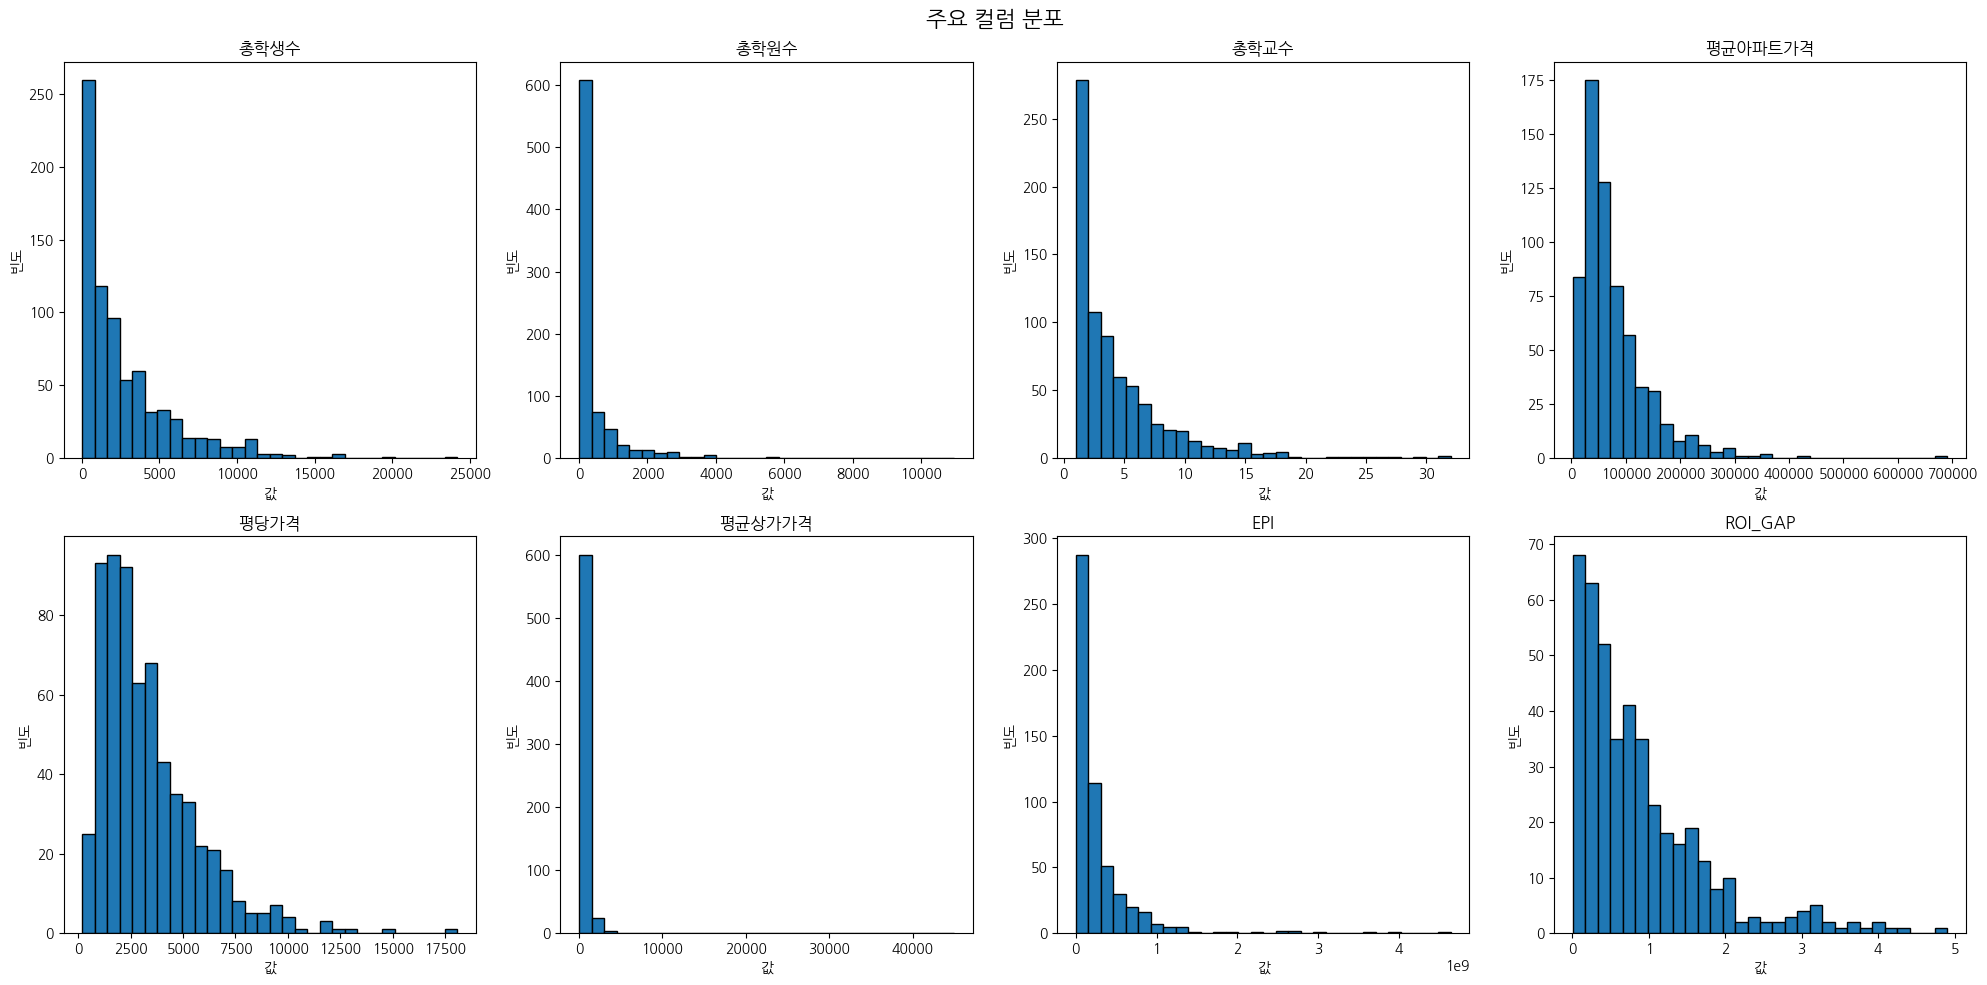

In [53]:
# 주요칼럼 히스토그램
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('주요 컬럼 분포', fontsize=16)

for i, col in enumerate(key_cols):
    ax = axes[i//4][i%4]
    data = final[col].dropna()
    ax.hist(data, bins=30, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('값')
    ax.set_ylabel('빈도')

plt.tight_layout()
plt.show()

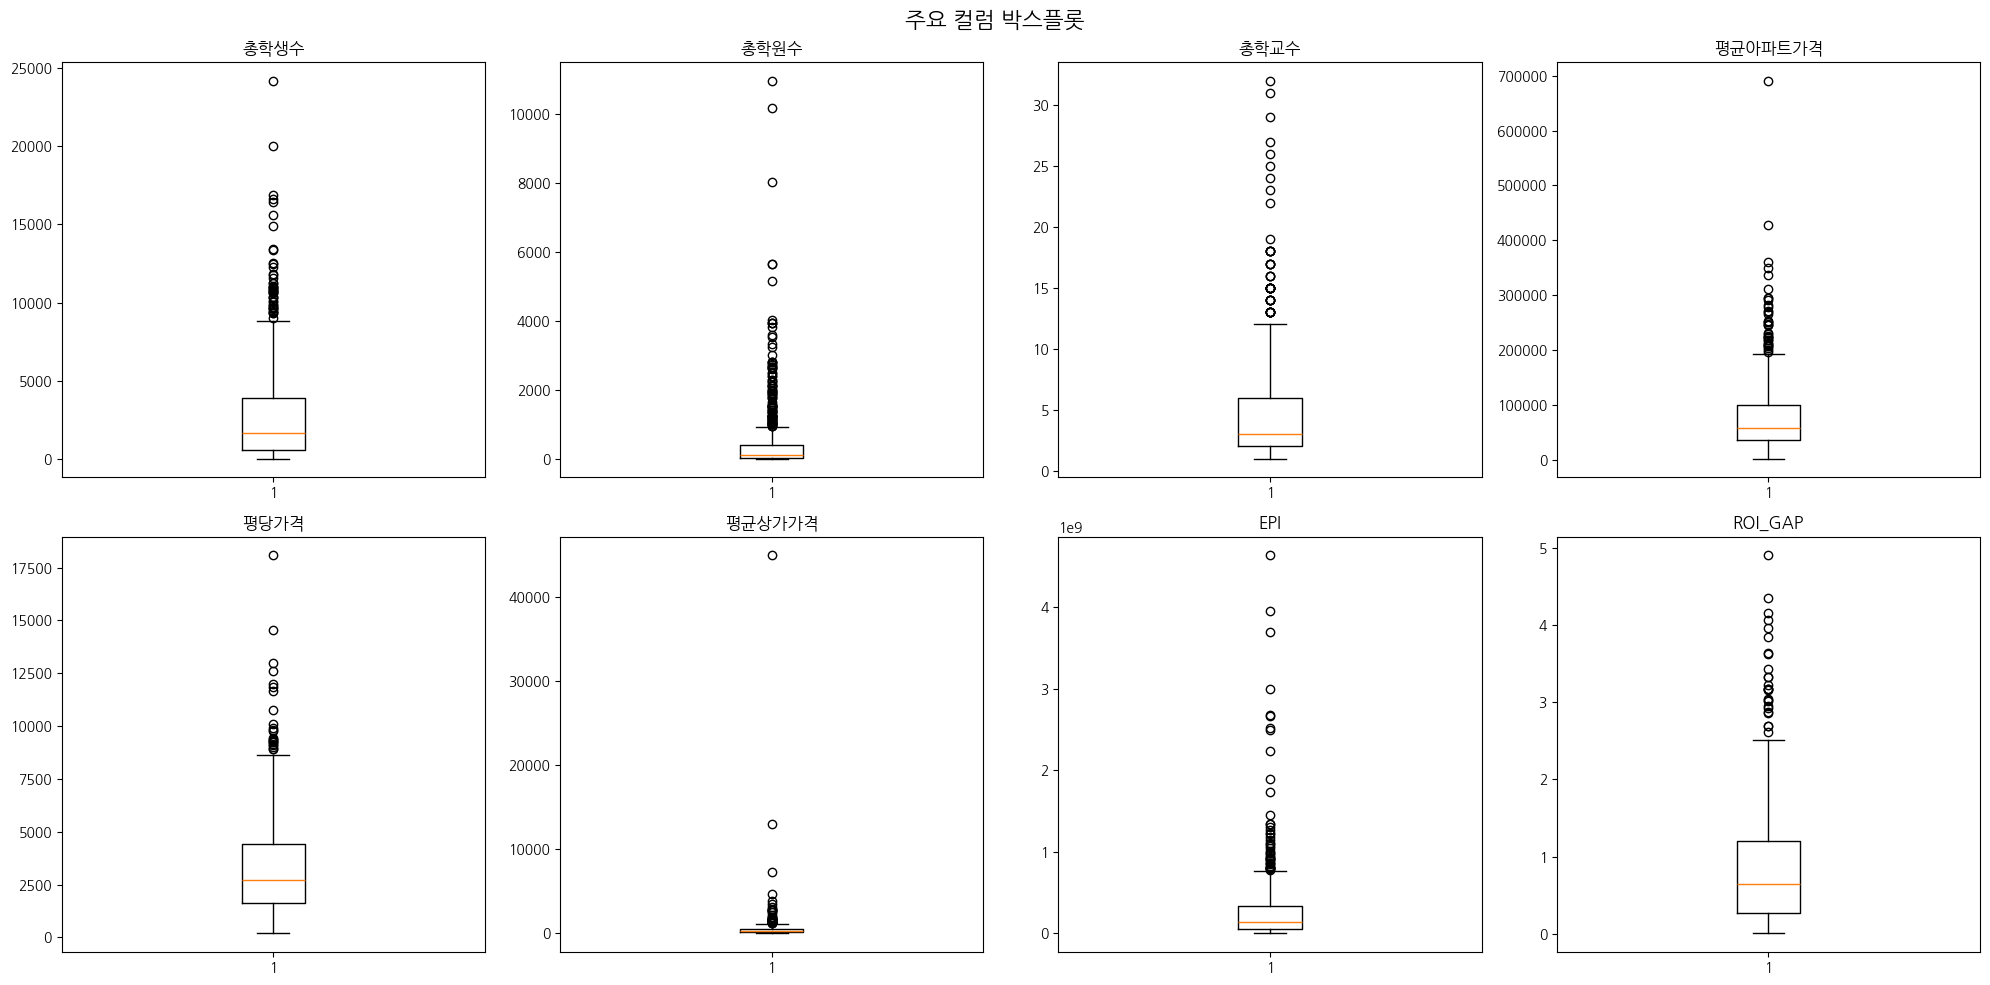

In [54]:
# 박스플롯
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('주요 컬럼 박스플롯', fontsize=16)

for i, col in enumerate(key_cols):
    ax = axes[i//4][i%4]
    data = final[col].dropna()
    ax.boxplot(data)
    ax.set_title(col)

plt.tight_layout()
plt.show()

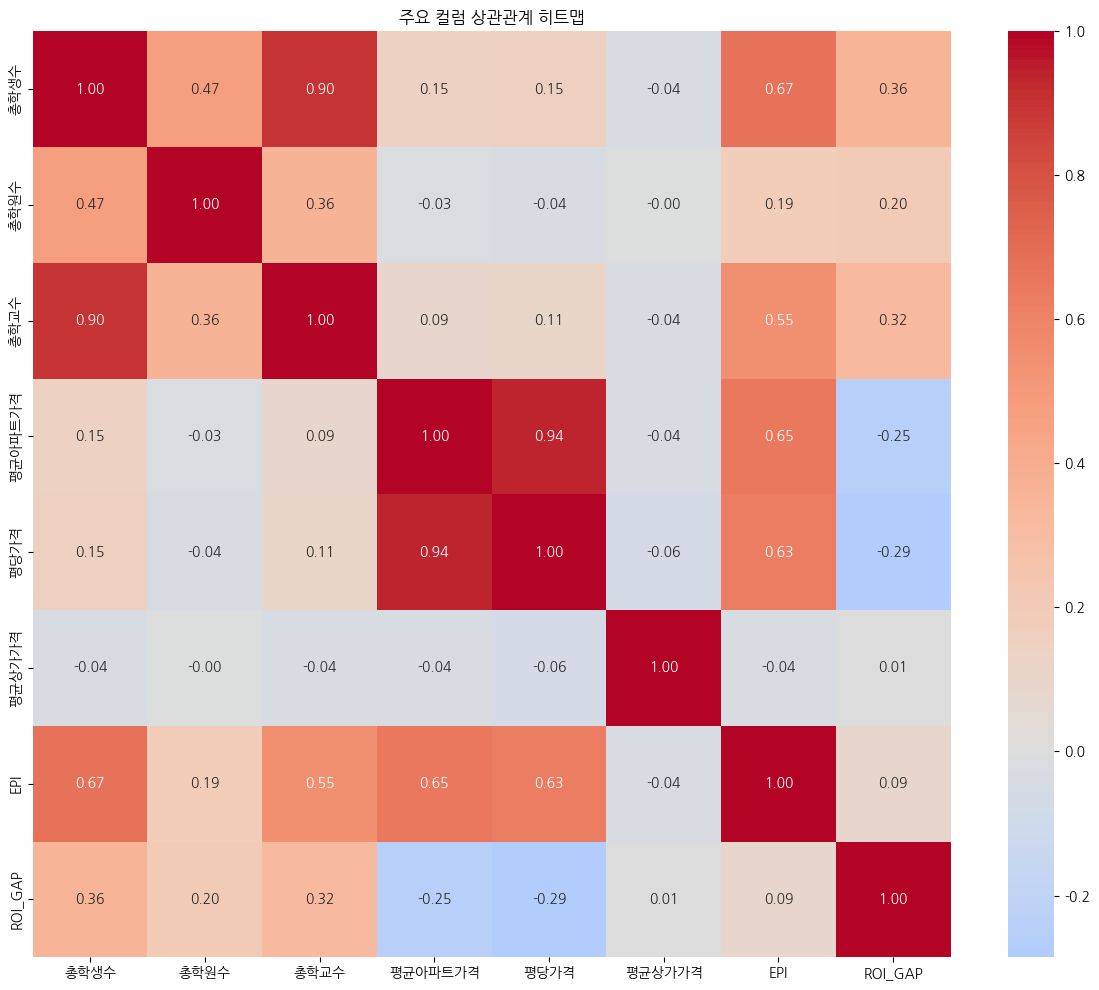

In [55]:
import seaborn as sns

# 상관관계
corr_matrix = final[key_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('주요 컬럼 상관관계 히트맵')
plt.tight_layout()
plt.show()

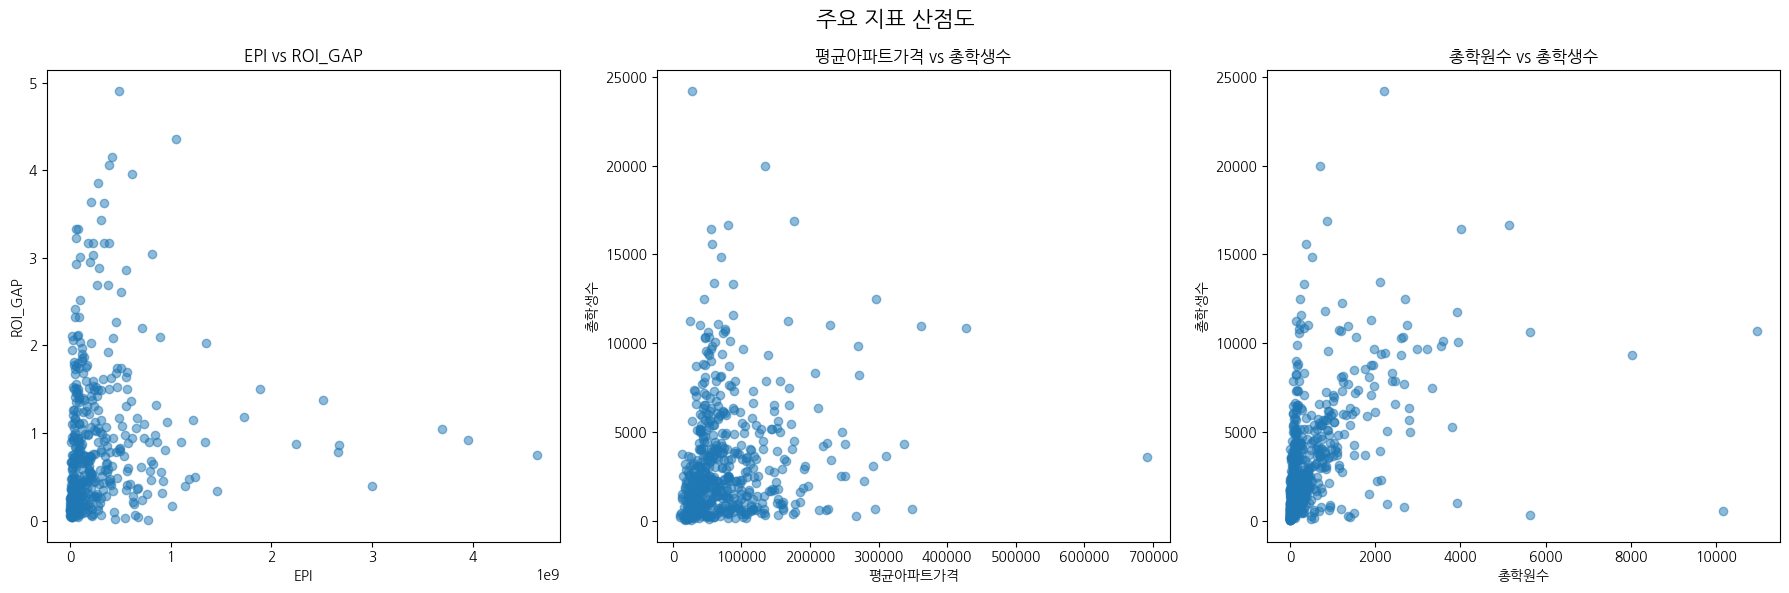

In [56]:
# 주요 칼럼 산점도
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('주요 지표 산점도', fontsize=16)

scatter_pairs = [('EPI', 'ROI_GAP'), ('평균아파트가격', '총학생수'), ('총학원수', '총학생수')]

for i, (x, y) in enumerate(scatter_pairs):
    data = final[[x, y]].dropna()
    axes[i].scatter(data[x], data[y], alpha=0.5)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}')

plt.tight_layout()
plt.show()

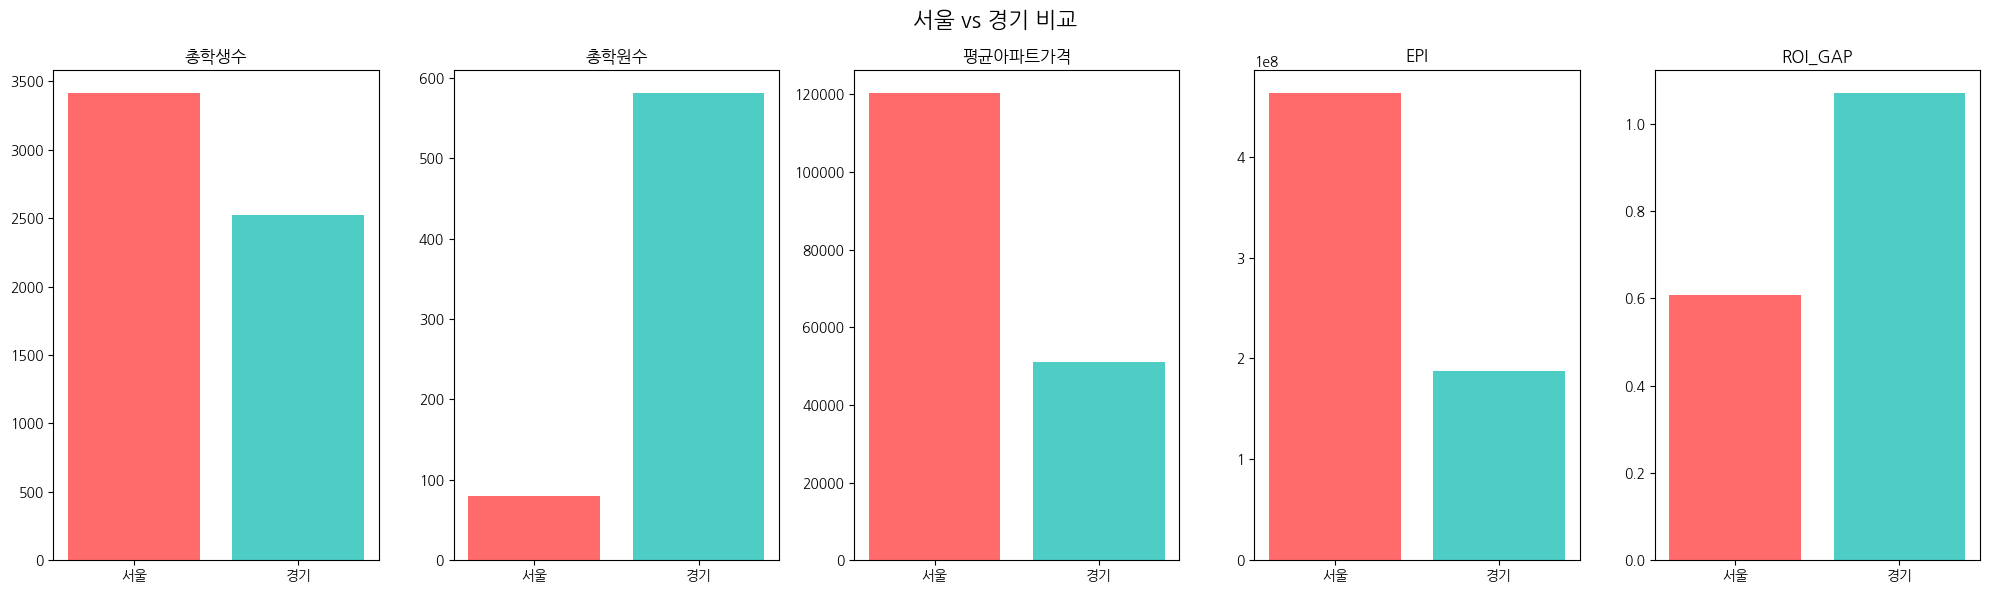

=== 서울 vs 경기 평균 비교 ===
                   서울            경기
총학생수     3.413540e+03  2.523460e+03
총학원수     8.012000e+01  5.810900e+02
평균아파트가격  1.202817e+05  5.108234e+04
EPI      4.630452e+08  1.879767e+08
ROI_GAP  6.100000e-01  1.070000e+00


In [57]:
# 서울 경기 주요 칼럼 비교
seoul = final[final['시도'].str.contains('서울', na=False)]
gyeonggi = final[final['시도'].str.contains('경기', na=False)]

compare_cols = ['총학생수', '총학원수', '평균아파트가격', 'EPI', 'ROI_GAP']
compare_df = pd.DataFrame({
    '서울': seoul[compare_cols].mean(),
    '경기': gyeonggi[compare_cols].mean()
})

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('서울 vs 경기 비교', fontsize=16)

for i, col in enumerate(compare_cols):
    axes[i].bar(['서울', '경기'], compare_df.loc[col], color=['#FF6B6B', '#4ECDC4'])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig(f'{base_path}eda_region_compare.png', dpi=150)
plt.show()

print("=== 서울 vs 경기 평균 비교 ===")
print(compare_df.round(2))

In [58]:
print("=== TOP10 동 ===")
for col in ['총학원수', '총학생수', 'EPI', 'ROI_GAP']:
    top10 = final.nlargest(10, col)[['시도', 'dong', col]]
    print(f"\n[{col} TOP10]")
    print(top10.to_string(index=False))

=== TOP10 동 ===

[총학원수 TOP10]
         시도 dong    총학원수
경기도 안양시 동안구  호계동 10954.0
    경기도 과천시  갈현동 10171.0
경기도 성남시 분당구  정자동  8024.0
경기도 수원시 영통구  영통동  5636.0
경기도 수원시 영통구  영통동  5636.0
   경기도 남양주시  다산동  5143.0
경기도 부천시 원미구   중동  4011.0
경기도 부천시 원미구   상동  3935.0
    경기도 화성시  반송동  3923.0
    경기도 화성시  반송동  3923.0

[총학생수 TOP10]
         시도 dong    총학생수
    경기도 시흥시  정왕동 24194.0
  서울특별시 양천구  신정동 19984.0
  서울특별시 양천구   목동 16901.0
   경기도 남양주시  다산동 16653.0
경기도 부천시 원미구   중동 16406.0
  서울특별시 노원구  상계동 15604.0
  서울특별시 노원구  중계동 14879.0
경기도 안양시 만안구  안양동 13419.0
  서울특별시 관악구  봉천동 13351.0
  서울특별시 송파구  잠실동 12504.0

[EPI TOP10]
       시도 dong          EPI
서울특별시 서초구  반포동 4.637097e+09
서울특별시 강남구  대치동 3.956518e+09
서울특별시 송파구  잠실동 3.696825e+09
서울특별시 양천구   목동 2.997348e+09
서울특별시 양천구  신정동 2.675899e+09
서울특별시 강남구  개포동 2.665703e+09
서울특별시 서초구  서초동 2.517433e+09
서울특별시 강남구 압구정동 2.497115e+09
서울특별시 강남구  도곡동 2.241886e+09
서울특별시 강동구  고덕동 1.889514e+09

[ROI_GAP TOP10]
         시도 dong  ROI_GAP
경기도 수원시 권선구  권선동 4.905260
  서울특별시 노원구  중계동

In [59]:
# ROI GAP이 상위권이면서 영어학원 경쟁도가 낮은 지역
roi_threshold = final['ROI_GAP'].quantile(0.75)
competition_threshold = final['실용외국어(유아/초·중·고)_학원경쟁도'].quantile(0.25)

result = final[
    (final['ROI_GAP'] >= roi_threshold) &
    (final['실용외국어(유아/초·중·고)_학원경쟁도'] <= competition_threshold)
][['시도', 'dong', 'ROI_GAP', 'ROI_GAP_상위%', '실용외국어(유아/초·중·고)_학원경쟁도', '실용외국어(유아/초·중·고)_학원경쟁도_상위%']].sort_values('ROI_GAP', ascending=False)

print(f"조건 충족 동: {len(result)}개")
print(result.to_string(index=False))

조건 충족 동: 22개
         시도 dong  ROI_GAP ROI_GAP_상위%  실용외국어(유아/초·중·고)_학원경쟁도 실용외국어(유아/초·중·고)_학원경쟁도_상위%
    경기도 평택시  이충동 3.332765        2.3%               3.432137                     79.6%
    경기도 평택시  세교동 3.012710        4.4%               1.396648                     95.0%
    경기도 양주시  덕계동 2.319676        6.9%               2.831079                     84.3%
경기도 부천시 원미구  도당동 2.115986        7.6%               3.552972                     78.3%
    경기도 평택시  지산동 2.057781        8.8%               1.667593                     94.0%
    경기도 김포시  북변동 2.036190        9.0%               3.674015                     76.9%
    경기도 평택시  서정동 1.811660       11.3%               0.953743                     97.0%
경기도 부천시 소사구 소사본동 1.758417       12.5%               3.351955                     80.3%
경기도 안산시 상록구   사동 1.689119       13.9%               2.820727                     84.6%
    경기도 시흥시  신천동 1.562394       15.7%               2.298851                     88.6%
경기도 용인시 기흥구  신갈동 1.540530     

# 유망지역 클러스터링

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

final = pd.read_csv(f'{base_path}final_with_indicators.csv')

# 클러스터링에 활용할 주요 칼럼
# 결측치는 드랍
feature_cols = ['EPI', 'ROI_GAP', '총학생수', '총학원수', '평균아파트가격']
df_cluster = final[feature_cols].dropna()

# 정규화 처리
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

print(f"클러스터링 대상: {len(df_cluster)}개 동")

클러스터링 대상: 427개 동


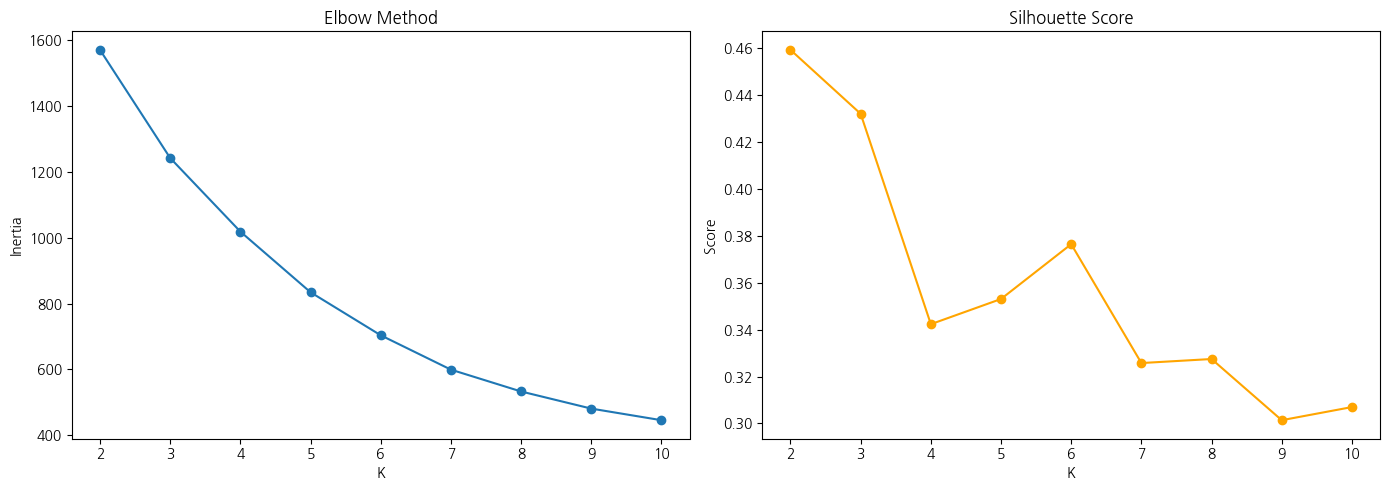

최적 K: 2 (Silhouette: 0.459)


In [61]:
inertia = []
silhouette = []

# 2~11 까지 클러스터 수별 실루엣 점수 계산
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, kmeans.labels_))

# 엘보우 방법으로 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 11), inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

# 실루엣 점수 시각화
axes[1].plot(range(2, 11), silhouette, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

best_k = silhouette.index(max(silhouette)) + 2
print(f"최적 K: {best_k} (Silhouette: {max(silhouette):.3f})")

In [62]:
# 6개 클러스터로 진행
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X)

print("=== 클러스터별 특성 ===")
print(df_cluster.groupby('cluster')[feature_cols].mean().round(2))

=== 클러스터별 특성 ===
                  EPI  ROI_GAP      총학생수     총학원수    평균아파트가격
cluster                                                     
0        1.094545e+08     0.55   1733.34   253.71   60163.85
1        6.143900e+08     0.64   9687.28  1585.81   67768.68
2        2.900801e+09     0.97  11993.60   468.80  254093.01
3        5.728428e+08     1.70   8151.67  6912.50   83283.41
4        5.446013e+08     0.43   3112.42   168.78  184078.51
5        2.440708e+08     2.23   4672.26   636.70   46225.25


In [63]:
# 각 클러스터별 이름 붙이기
label_map = {
    0: '교육불모지',
    1: '교육밀집지',
    2: '블루오션',
    3: '레드오션',
    4: '잠재성장지',
    5: '교육활성지'
}

# 클러스터별 라벨링
df_cluster['cluster_label'] = df_cluster['cluster'].map(label_map)
final = final.join(df_cluster[['cluster', 'cluster_label']])

In [64]:
# 인구 데이터 칼럼
pop_cols = ['총인구', '노령화지수', '10세미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세이상', '평균나이']

# 값은 앞에 값으로 상위 값은 뒤에 값으로 새로운 칼럼생성
for col in pop_cols:
    final[f'{col}_값'] = final[col].apply(lambda x: float(re.search(r'[\d.]+', str(x)).group()) if pd.notna(x) and re.search(r'[\d.]+', str(x)) else None)
    final[f'{col}_상위%'] = final[col].apply(lambda x: re.search(r'상위 ([\d.]+%)', str(x)).group(1) if pd.notna(x) and re.search(r'상위 ([\d.]+%)', str(x)) else None)
    final = final.drop(columns=[col])

# 칼럼에서 ? 는 / 로 바꾸기
final.columns = [col.replace('?', '/') for col in final.columns]

final.to_csv(f'{base_path}final_with_cluster.csv', index=False, encoding='utf-8-sig')
print("저장 완료")
print([col for col in final.columns if '/' in col][:10])

저장 완료
['경영/사무관리', '독서실(유아/초/중/고)', '보습/논술', '실용외국어(유아/초/중/고)', '이/미용', '입시/논술', '독서실(유아/초·중·고)', '실용외국어(유아/초·중·고)', '경영/사무관리_학원경쟁도', '독서실(유아/초/중/고)_학원경쟁도']


# JSON 형식으로 데이터 저장

In [65]:
import json
import os

final = pd.read_csv(f'{base_path}final_with_cluster.csv')

# 경쟁도 칼럼과 상위 퍼센트 칼럼 추출
경쟁도_cols = [col for col in final.columns if col.endswith('_학원경쟁도')]
상위_cols = [col for col in final.columns if col.endswith('_상위%')]

# 학원 종류 칼럼 추출
academy_cols = [col for col in final.columns if col not in [
    '시도', 'dong', '노령화지수', '평균나이', '총인구', '총주택(거처)수',
    '10세미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세이상',
    '평균아파트가격', '평당가격', '거래건수', '평균상가가격', '상가평당가격', '상가거래건수',
    '초등학생수', '중학생수', '고등학생수', '초등학교수', '중학교수', '고등학교수', '총학생수', '총학교수',
    '총학원수', 'EPI', 'EPI_상위%', 'ROI_GAP', 'ROI_GAP_상위%', 'cluster', 'cluster_label'
] if not col.endswith('_학원경쟁도') and not col.endswith('_상위%')]

print(f"학원 종류: {len(academy_cols)}개")
print(f"경쟁도 컬럼: {len(경쟁도_cols)}개")
print(f"상위% 컬럼: {len(상위_cols)}개")

학원 종류: 143개
경쟁도 컬럼: 129개
상위% 컬럼: 145개


In [66]:
# 기본 칼럼 정의
pop_cols = ['총인구', '10세미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세이상', '평균나이', '노령화지수']

base_info_cols = [
    '총주택(거처)수',
    '초등학생수', '중학생수', '고등학생수', '총학생수',
    '초등학교수', '중학교수', '고등학교수', '총학교수',
    '총학원수', '평균아파트가격', '평당가격', '거래건수',
    '평균상가가격', '상가평당가격', '상가거래건수',
    'EPI', 'EPI_상위%', 'ROI_GAP', 'ROI_GAP_상위%',
    'cluster', 'cluster_label'
]

for col in pop_cols:
    base_info_cols.append(f'{col}_값')
    base_info_cols.append(f'{col}_상위%')

base_info_cols = [col for col in base_info_cols if col in final.columns]
print(f"base_info_cols: {len(base_info_cols)}개")

base_info_cols: 50개


In [67]:
import json

dong_data = {}

# json 형식으로 저장
for _, row in final.iterrows():
    key = f"{row['시도']}_{row['dong']}"

    entry = {'시도': row['시도'], 'dong': row['dong']}

    # 기본 칼럼들 데이터 저장
    for col in base_info_cols:
        val = row.get(col)
        entry[col] = None if pd.isna(val) else val

    # 종류별 학원 수 저장
    entry['학원수별'] = {}
    for col in academy_cols:
        val = row.get(col)
        if not pd.isna(val) and val > 0:
            entry['학원수별'][col] = val

    # 종류별 학원 경쟁도 저장
    entry['학원경쟁도별'] = {}
    for col in 경쟁도_cols:
        val = row.get(col)
        academy_name = col.replace('_경쟁도', '')
        if not pd.isna(val) and val > 0:
            entry['학원경쟁도별'][academy_name] = round(val, 4)

    dong_data[key] = entry

print(f"총 동 개수: {len(dong_data)}")
print(f"\n샘플 (대치동):")
sample_key = [k for k in dong_data.keys() if '대치' in k]
if sample_key:
    sample = dong_data[sample_key[0]]
    print(f"  시도: {sample['시도']}")
    print(f"  dong: {sample['dong']}")
    print(f"  총학생수: {sample['총학생수']}")
    print(f"  EPI: {sample['EPI']}")
    print(f"  cluster_label: {sample['cluster_label']}")
    print(f"  학원수별 종류: {len(sample['학원수별'])}개")
    print(f"  학원경쟁도별 종류: {len(sample['학원경쟁도별'])}개")

총 동 개수: 970

샘플 (대치동):
  시도: 서울특별시 강남구
  dong: 대치동
  총학생수: 10953.0
  EPI: 3956517741.048388
  cluster_label: 블루오션
  학원수별 종류: 46개
  학원경쟁도별 종류: 32개


In [68]:
# 데이터를 json 파일로 저장
with open(f'{base_path}dong_data.json', 'w', encoding='utf-8') as f:
    json.dump(dong_data, f, ensure_ascii=False, indent=2, default=str)

import os
file_size = os.path.getsize(f'{base_path}dong_data.json') / 1024 / 1024
print(f"저장 완료: dong_data.json ({file_size:.1f} MB)")

저장 완료: dong_data.json (2.4 MB)


# 행정동 경계 데이터 geojson형식으로 변환

In [69]:
import geopandas as gpd
import json
import re
import pandas as pd

# 데이터를 좌표기준계를 변경
gdf_seoul = gpd.read_file(f'{base_path}LSMD_ADM_SECT_UMD_11_202602.shp', encoding='cp949')
gdf_gg = gpd.read_file(f'{base_path}LSMD_ADM_SECT_UMD_41_202602.shp', encoding='cp949')
gdf_seoul = gdf_seoul.to_crs(epsg=4326)
gdf_gg = gdf_gg.to_crs(epsg=4326)

# 데이터 병합
gdf = pd.concat([gdf_seoul, gdf_gg], ignore_index=True)

with open(f'{base_path}dong_data.json', 'r', encoding='utf-8') as f:
    dong_data = json.load(f)

In [70]:
# 코드와 구이름 매핑
sigungu_code_map = {
    '11110': '종로구', '11140': '중구', '11170': '용산구', '11200': '성동구',
    '11215': '광진구', '11230': '동대문구', '11260': '중랑구', '11290': '성북구',
    '11305': '강북구', '11320': '도봉구', '11350': '노원구', '11380': '은평구',
    '11410': '서대문구', '11440': '마포구', '11470': '양천구', '11500': '강서구',
    '11530': '구로구', '11545': '금천구', '11560': '영등포구', '11590': '동작구',
    '11620': '관악구', '11650': '서초구', '11680': '강남구', '11710': '송파구', '11740': '강동구',
    '41011': '수원시 장안구', '41013': '수원시 권선구', '41015': '수원시 팔달구', '41117': '수원시 영통구',
    '41131': '성남시 수정구', '41133': '성남시 중원구', '41135': '성남시 분당구',
    '41150': '의정부시', '41171': '안양시 만안구', '41173': '안양시 동안구',
    '41191': '부천시 오정구', '41193': '부천시 원미구', '41195': '부천시 소사구',
    '41210': '광명시', '41220': '평택시', '41250': '동두천시',
    '41271': '안산시 상록구', '41273': '안산시 단원구',
    '41281': '고양시 덕양구', '41285': '고양시 일산동구', '41287': '고양시 일산서구',
    '41290': '과천시', '41310': '구리시', '41360': '남양주시', '41370': '오산시',
    '41390': '시흥시', '41410': '군포시', '41430': '의왕시', '41450': '하남시',
    '41461': '용인시 처인구', '41463': '용인시 기흥구', '41465': '용인시 수지구',
    '41480': '파주시', '41500': '이천시', '41550': '안성시', '41570': '김포시',
    '41590': '화성시', '41610': '광주시', '41630': '양주시', '41650': '포천시',
    '41670': '여주시', '41800': '연천군', '41820': '가평군', '41830': '양평군'
}

sigungu_code_map.update({
    '41111': '수원시 장안구',
    '41113': '수원시 권선구',
    '41115': '수원시 팔달구',
    '41117': '수원시 영통구',
    '41131': '성남시 수정구',
    '41133': '성남시 중원구',
    '41135': '성남시 분당구',
    '41591': '화성시',
    '41593': '화성시',
    '41595': '화성시',
    '41597': '화성시',
    '41192': '부천시',
    '41194': '부천시',
    '41196': '부천시',
})

sido_map = {'11': '서울특별시', '41': '경기도'}

In [71]:
# gdf 파일에서 시도코드(앞2자리)와 시군구코드(앞5자리) 추출
gdf['sido_code'] = gdf['EMD_CD'].astype(str).str[:2]
gdf['sigungu_code'] = gdf['EMD_CD'].astype(str).str[:5]

# 시도 매핑에서 탐색후 코드를 치환
gdf['sido'] = gdf['sido_code'].map(sido_map)
gdf['sigungu'] = gdf['sigungu_code'].map(sigungu_code_map)

# 시도와 시군구 합치기
gdf['시도'] = gdf['sido'] + ' ' + gdf['sigungu']
gdf['dong'] = gdf['EMD_NM'].apply(
    lambda x: re.sub(r'[0-9\.·]+[가]*동$', '동', str(x)) if str(x).endswith(('동', '읍', '면')) else str(x)
)
gdf['key'] = gdf['시도'] + '_' + gdf['dong']

In [72]:
# key=시도+동
dong_keys = set(dong_data.keys())
geo_keys = set(gdf['key'])

# 둘다 존재하는 시도동 = common
common = dong_keys & geo_keys

# 매칭 하기
print(f"매칭 동: {len(common)}개 / {len(dong_keys)}개")
print(f"NaN 시도: {gdf['시도'].isna().sum()}개")

print(f"\n남은 NaN 시군구 코드:")
print(gdf[gdf['시도'].isna()]['sigungu_code'].value_counts())

매칭 동: 947개 / 970개
NaN 시도: 0개

남은 NaN 시군구 코드:
Series([], Name: count, dtype: int64)


In [73]:
# gdf와 dong_data의 keys가 isin하는걸 변수명에 저장
gdf_matched = gdf[gdf['key'].isin(dong_data.keys())].copy()
gdf_unmatched = gdf[~gdf['key'].isin(dong_data.keys())].copy()

print(f"매칭된 동: {len(gdf_matched)}개")
print(f"매칭 안된 GeoJSON 동: {len(gdf_unmatched)}개")

매칭된 동: 949개
매칭 안된 GeoJSON 동: 264개


In [74]:
# dong_data를 json형식으로 변환
features = []

for _, row in gdf_matched.iterrows():
    key = row['key']
    data = dong_data.get(key, {})

    feature = {
        'type': 'Feature',
        'geometry': row['geometry'].__geo_interface__,
        'properties': {
            'key': key,
            '시도': row['시도'],
            'dong': row['dong'],
            **{k: v for k, v in data.items() if k not in ['학원수별', '학원경쟁도별']},
            '학원수별': data.get('학원수별', {}),
            '학원경쟁도별': data.get('학원경쟁도별', {})
        }
    }
    features.append(feature)

In [75]:
# geojson 형식으로 저장
geojson = {
    'type': 'FeatureCollection',
    'features': features
}

with open(f'{base_path}dong_map.geojson', 'w', encoding='utf-8') as f:
    json.dump(geojson, f, ensure_ascii=False)

import os
file_size = os.path.getsize(f'{base_path}dong_map.geojson') / 1024 / 1024
print(f"저장 완료: dong_map.geojson ({file_size:.1f} MB)")
print(f"총 feature 수: {len(features)}")

저장 완료: dong_map.geojson (21.8 MB)
총 feature 수: 949


# (추가)부천시 지역 경계 데이터 추가

In [76]:
# 부천의 dong_data파일과 gdf파일의 부천 출력
print("부천 매칭 현황:")
부천_dong = {k: v for k, v in dong_data.items() if '부천' in k}
print(f"dong_data 부천 동 수: {len(부천_dong)}개")

부천_geo = gdf[gdf['시도'].str.contains('부천', na=False)]
print(f"GeoJSON 부천 동 수: {len(부천_geo)}개")

not_matched = set(부천_dong.keys()) - set(gdf_matched['key'])
print(f"\n매칭 안된 부천 동:")
for k in sorted(not_matched):
    print(f"  {k}")

부천 매칭 현황:
dong_data 부천 동 수: 22개
GeoJSON 부천 동 수: 24개

매칭 안된 부천 동:
  경기도 부천시 소사구_괴안동
  경기도 부천시 소사구_범박동
  경기도 부천시 소사구_소사본동
  경기도 부천시 소사구_송내동
  경기도 부천시 소사구_심곡본동
  경기도 부천시 소사구_옥길동
  경기도 부천시 오정구_고강동
  경기도 부천시 오정구_내동
  경기도 부천시 오정구_삼정동
  경기도 부천시 오정구_여월동
  경기도 부천시 오정구_오정동
  경기도 부천시 오정구_원종동
  경기도 부천시 오정구_작동
  경기도 부천시 원미구_도당동
  경기도 부천시 원미구_상동
  경기도 부천시 원미구_소사동
  경기도 부천시 원미구_심곡동
  경기도 부천시 원미구_약대동
  경기도 부천시 원미구_역곡동
  경기도 부천시 원미구_원미동
  경기도 부천시 원미구_중동
  경기도 부천시 원미구_춘의동


In [77]:
# 부천 키 출력
print("GeoJSON 부천 키 샘플:")
print(gdf[gdf['시도'].str.contains('부천', na=False)]['key'].head(10).tolist())

GeoJSON 부천 키 샘플:
['경기도 부천시_원미동', '경기도 부천시_심곡동', '경기도 부천시_심곡본동', '경기도 부천시_중동', '경기도 부천시_상동', '경기도 부천시_약대동', '경기도 부천시_도당동', '경기도 부천시_계수동', '경기도 부천시_여월동', '경기도 부천시_춘의동']


In [78]:
# dong_data의 구 데이터는 없애기
new_dong_data = {}
for key, val in dong_data.items():
    if '부천시 오정구' in key or '부천시 원미구' in key or '부천시 소사구' in key:
        new_key = key.replace('부천시 오정구', '부천시').replace('부천시 원미구', '부천시').replace('부천시 소사구', '부천시')
        val['시도'] = new_key.split('_')[0]
        new_dong_data[new_key] = val
    else:
        new_dong_data[key] = val

dong_data = new_dong_data

print(f"부천 키 샘플:")
for k in [k for k in dong_data.keys() if '부천' in k][:5]:
    print(f"  {k}")

common = set(dong_data.keys()) & set(gdf['key'])
print(f"\n매칭 동: {len(common)}개 / {len(dong_data)}개")

부천 키 샘플:
  경기도 부천시_괴안동
  경기도 부천시_범박동
  경기도 부천시_소사본동
  경기도 부천시_송내동
  경기도 부천시_심곡본동

매칭 동: 969개 / 970개


In [79]:
# dong_data와 gdf의 매칭이 되는 키 데이터를 geojson 형식으로 저장
features = []

for _, row in gdf.iterrows():
    key = row['key']
    if key not in dong_data:
        continue
    data = dong_data.get(key, {})

    feature = {
        'type': 'Feature',
        'geometry': row['geometry'].__geo_interface__,
        'properties': {
            'key': key,
            '시도': row['시도'],
            'dong': row['dong'],
            **{k: v for k, v in data.items() if k not in ['학원수별', '학원경쟁도별']},
            '학원수별': data.get('학원수별', {}),
            '학원경쟁도별': data.get('학원경쟁도별', {})
        }
    }
    features.append(feature)

geojson = {
    'type': 'FeatureCollection',
    'features': features
}

with open(f'{base_path}dong_map.geojson', 'w', encoding='utf-8') as f:
    json.dump(geojson, f, ensure_ascii=False)

file_size = os.path.getsize(f'{base_path}dong_map.geojson') / 1024 / 1024
print(f"저장 완료: dong_map.geojson ({file_size:.1f} MB)")
print(f"총 feature 수: {len(features)}")

저장 완료: dong_map.geojson (22.2 MB)
총 feature 수: 971


# (추가) 정규화 진행 - 각 데이터의 편차가 커, 맵의 색이 극단적으로 나뉘는 현상 방지

### 연령대 칼럼 단순화

In [80]:
# 연령대 합산
final['유아_값'] = final['10세미만_값']
final['초중고_값'] = final['10대_값']
final['청년_값'] = final['20대_값'] + final['30대_값']
final['중장년_값'] = final['40대_값'] + final['50대_값']
final['노년_값'] = final[['60대_값', '70대_값', '80대_값', '90대_값', '100세이상_값']].sum(axis=1)

# 기존 컬럼 제거
drop_cols = [
    '10세미만_값', '10대_값', '20대_값', '30대_값', '40대_값', '50대_값',
    '60대_값', '70대_값', '80대_값', '90대_값', '100세이상_값',
    '10세미만_상위%', '10대_상위%', '20대_상위%', '30대_상위%', '40대_상위%', '50대_상위%',
    '60대_상위%', '70대_상위%', '80대_상위%', '90대_상위%', '100세이상_상위%',
    '노령화지수'
]
drop_cols = [col for col in drop_cols if col in final.columns]
final = final.drop(columns=drop_cols)

In [81]:
from sklearn.preprocessing import QuantileTransformer
import numpy as np

# 타겟 칼럼 지정
exclude_cols = ['시도', 'dong', 'cluster', 'cluster_label']
numeric_cols = [
    col for col in final.columns
    if col not in exclude_cols
    and not col.endswith('_상위%')
    and final[col].dtype in ['int64', 'float64']
]

# 분위수 정규화 진행
qt = QuantileTransformer(output_distribution='uniform', random_state=42)
final_normalized = final.copy()
final_normalized[numeric_cols] = qt.fit_transform(final[numeric_cols].fillna(0))
final_normalized.to_csv(f'{base_path}final_normalized.csv', index=False, encoding='utf-8-sig')

In [82]:
base_skip = [
    '시도', 'dong', 'cluster', 'cluster_label', '학교교과교습학원',
    '총학원수', '총학생수', '총학교수', '초등학생수', '중학생수', '고등학생수',
    '초등학교수', '중학교수', '고등학교수', '총주택(거처)수', '인구밀도',
    '평균아파트가격', '평당가격', '거래건수', '평균상가가격', '상가평당가격', '상가거래건수',
    'EPI', 'ROI_GAP', 'BOI'
]

# base_skip 칼럼과 상위, 학원 경쟁도가 들어간 칼럼 제외 = 학원 칼럼
academy_cols = [
    col for col in final.columns
    if col not in base_skip
    and not col.endswith('_상위%')
    and not col.endswith('_학원경쟁도')
    and not any(col.startswith(p) for p in ['총인구', '평균나이', '10세', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세', '노령화', '유아', '초중고', '청년', '중장년', '노년'])
    and final[col].dtype in ['int64', 'float64']
    and final[col].sum() > 0
]

print(f"학원 종류 컬럼 ({len(academy_cols)}개): {academy_cols[:5]}")

학원 종류 컬럼 (125개): ['간호조무사', '건축', '검정', '게임', '경리']


In [83]:
# 기존의 동 데이터
dong_data = {}
for _, row in final_normalized.iterrows():
    key = f"{row['시도']}_{row['dong']}"
    entry = {col: (None if pd.isna(row.get(col)) else row.get(col)) for col in final_normalized.columns if col not in ['시도', 'dong']}
    entry['시도'] = row['시도']
    entry['dong'] = row['dong']
    entry['학원수별'] = {col: int(final.loc[row.name, col]) for col in academy_cols if not pd.isna(final.loc[row.name, col]) and final.loc[row.name, col] > 0}
    entry['학원경쟁도별'] = {col.replace('_학원경쟁도', ''): round(float(row[col]), 4) for col in 경쟁도_cols if not pd.isna(row[col])}
    dong_data[key] = entry

# 부천시 동 데이터는 따로(구 정보가 없음))
new_dong_data = {}
for key, val in dong_data.items():
    if any(x in key for x in ['부천시 오정구', '부천시 원미구', '부천시 소사구']):
        new_key = key.replace('부천시 오정구', '부천시').replace('부천시 원미구', '부천시').replace('부천시 소사구', '부천시')
        val['시도'] = new_key.split('_')[0]
        new_dong_data[new_key] = val
    else:
        new_dong_data[key] = val
dong_data = new_dong_data

In [84]:
features = [
    {
        'type': 'Feature',
        'geometry': row['geometry'].__geo_interface__,
        'properties': {
            'key': row['key'], '시도': row['시도'], 'dong': row['dong'],
            **{k: v for k, v in dong_data[row['key']].items() if k not in ['학원수별', '학원경쟁도별']},
            '학원수별': dong_data[row['key']].get('학원수별', {}),
            '학원경쟁도별': dong_data[row['key']].get('학원경쟁도별', {})
        }
    }
    for _, row in gdf.iterrows() if row['key'] in dong_data
]

geojson = {'type': 'FeatureCollection', 'features': features}
with open(f'{base_path}dong_map.geojson', 'w', encoding='utf-8') as f:
    json.dump(geojson, f, ensure_ascii=False)

print(f"{os.path.getsize(f'{base_path}dong_map.geojson') / 1024 / 1024:.1f} MB, {len(features)}개 동")

36.7 MB, 971개 동


# (추가) 지표 생성 & 새로운 클러스터링

##### 각 법정동들이 결측치를 제일 적게 가지고있는 칼럼값들로 진행

##### 마찬가지로 클러스터링을 결측치가 없는 칼럼으로 진행

In [85]:
# 결측치가 아니고 0의 값이 아닌 값
coverage = (final_normalized.notna() & (final_normalized != 0)).sum() / len(final_normalized) * 100

# 결측치가 없는 값이 80%이상인 칼럼
print(coverage[coverage >= 60].sort_values(ascending=False).to_string())

시도              100.000000
dong            100.000000
평균나이_상위%        100.000000
총인구_상위%         100.000000
중장년_값            99.899900
평균나이_값           99.899900
총인구_값            99.799800
노년_값             99.699700
청년_값             99.299299
초중고_값            98.298298
노령화지수_값          98.098098
노령화지수_상위%        98.098098
유아_값             97.597598
총학원수             81.381381
상가거래건수           76.676677
총학교수             76.476476
총학생수             76.476476
보습               69.869870
초등학생수            69.869870
초등학교수            69.869870
음악               67.567568
평균아파트가격          64.364364
거래건수             64.364364
평당가격             64.364364
보습_학원경쟁도_상위%     64.164164
보습_학원경쟁도         64.164164
상가평당가격           63.163163
평균상가가격           63.163163
음악_학원경쟁도_상위%     62.762763
음악_학원경쟁도         62.762763


In [86]:
print(feature_cols)

['EPI', 'ROI_GAP', '총학생수', '총학원수', '평균아파트가격']


In [87]:
# 새로운 학원밀도와 유소년비율 지수 계산
final['학원밀도'] = final['총학원수'] / final['총인구_값'].replace(0, None)
final['유소년비율'] = (final['유아_값'] + final['초중고_값']) / final['총인구_값'].replace(0, None)
final['유소년수'] = final['유아_값'] + final['초중고_값']

각 클러스터 타겟 변수별 이상치 지역은 제외하고 진행

In [88]:
final = final[~((final['시도'].str.contains('남양주시')) & (final['dong'] == '도농동'))].copy()
final = final[~((final['시도'].str.contains('남양주시')) & (final['dong'] == '지금동'))].copy()
exclude_list = [('과천시', '갈현동'), ('종로구', '서린동'), ('중구', '소공동')]
for 시도_keyword, dong in exclude_list:
    final = final[~((final['시도'].str.contains(시도_keyword)) & (final['dong'] == dong))].copy()
final = final[final['총인구_값'] >= 1000].copy()

클러스터 특성에 어울리는 타겟변수 추출

In [123]:
# 타겟 칼럼
feature_cols = ['총인구_값', '초중고_값', '유소년수', '총학원수', '학원밀도', '평균아파트가격', '총학생수']

# 결측치는 0으로 처리와 정규화 처리
df_cluster = final[feature_cols].fillna(0)
X = StandardScaler().fit_transform(df_cluster)

# 클러스터링
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
final['cluster'] = kmeans.fit_predict(X)

print(final.groupby('cluster')[feature_cols].mean().round(2))

# 각 클러스터 라벨링
label_map = {
    0: '소규모주거지',
    1: '학원밀집지',
    2: '일반주거지',
    3: '블루오션',
    4: '교육저활성지',
    5: '고급주거지'
}

final['cluster_label'] = final['cluster'].map(label_map)

exclude_cols = ['시도', 'dong', 'cluster', 'cluster_label']
numeric_cols = [
    col for col in final.columns
    if col not in exclude_cols
    and not col.endswith('_상위%')
    and final[col].dtype in ['int64', 'float64']
]

qt = QuantileTransformer(output_distribution='uniform', random_state=42)
final_normalized = final.copy()
final_normalized[numeric_cols] = qt.fit_transform(final[numeric_cols].fillna(0))
final_normalized.to_csv(f'{base_path}final_normalized.csv', index=False, encoding='utf-8-sig')

print(final_normalized['cluster_label'].value_counts())

             총인구_값     초중고_값      유소년수     총학원수  학원밀도    평균아파트가격      총학생수
cluster                                                                   
0         10818.19    785.66   1306.31    77.13  0.01   40523.13    990.67
1         67955.65   8030.23  13024.38  2633.10  0.04   72972.33   7974.19
2         55420.56   4804.80   8019.10   479.18  0.01   81808.75   4660.73
3        131602.92  12046.36  18886.72   825.72  0.01  142412.24  12028.88
4         21399.57   2139.85   3622.86   608.87  0.03   51883.78   2324.15
5         16628.35   1263.81   2214.72    60.75  0.00  159465.74   1651.90
cluster_label
소규모주거지    415
일반주거지     164
고급주거지     109
교육저활성지     92
학원밀집지      48
블루오션       25
Name: count, dtype: int64


In [124]:
# 각 클러스터 변수별 평균값 출력
print(final.groupby('cluster')[['총인구_값','총학원수','학원밀도','평균아파트가격']].mean().round(2))

             총인구_값     총학원수  학원밀도    평균아파트가격
cluster                                     
0         10818.19    77.13  0.01   40523.13
1         67955.65  2633.10  0.04   72972.33
2         55420.56   479.18  0.01   81808.75
3        131602.92   825.72  0.01  142412.24
4         21399.57   608.87  0.03   51883.78
5         16628.35    60.75  0.00  159465.74


In [125]:
# 시도동의 클러스터 라벨을 클러스터라벨 순서대로 출력
print(final['cluster_label'].value_counts())
print(final[['시도', 'dong', 'cluster_label']].sort_values('cluster_label').to_string())

cluster_label
소규모주거지    415
일반주거지     164
고급주거지     109
교육저활성지     92
학원밀집지      48
블루오션       25
Name: count, dtype: int64
               시도   dong cluster_label
789     서울특별시 마포구    신수동         고급주거지
714     서울특별시 강서구    가양동         고급주거지
837     서울특별시 성동구    행당동         고급주거지
219   경기도 성남시 중원구    중앙동         고급주거지
836     서울특별시 성동구  하왕십리동         고급주거지
835     서울특별시 성동구    응봉동         고급주거지
834     서울특별시 성동구    용답동         고급주거지
842     서울특별시 성북구    석관동         고급주거지
833     서울특별시 성동구    옥수동         고급주거지
831     서울특별시 성동구  상왕십리동         고급주거지
199   경기도 성남시 수정구    고등동         고급주거지
828     서울특별시 성동구    도선동         고급주거지
826     서울특별시 서초구    우면동         고급주거지
824     서울특별시 서초구    양재동         고급주거지
823     서울특별시 서초구    양재동         고급주거지
832     서울특별시 성동구    송정동         고급주거지
822     서울특별시 서초구    신원동         고급주거지
850     서울특별시 송파구    마천동         고급주거지
854     서울특별시 송파구    석촌동         고급주거지
869    서울특별시 영등포구   여의도동         고급주거지
866    서울특별시 영등포구    도림동         고급주거지
865    서울특별시 영등포구 

In [126]:
# 상위 1퍼센트 클리핑
for col in ['학원밀도', '총학원수', '상가거래건수', '청년_값', '노년_값', '평균상가가격', '상가평당가격']:
    upper = final[col].quantile(0.99)
    final[col] = final[col].clip(upper=upper)

In [106]:
# 다시 dong_map.geojson 파일로 저장
경쟁도_cols = [col for col in final.columns if col.endswith('_학원경쟁도')]

base_skip = [
    '시도', 'dong', 'cluster', 'cluster_label', '학교교과교습학원',
    '총학원수', '총학생수', '총학교수', '초등학생수', '중학생수', '고등학생수',
    '초등학교수', '중학교수', '고등학교수', '총주택(거처)수', '인구밀도',
    '평균아파트가격', '평당가격', '거래건수', '평균상가가격', '상가평당가격', '상가거래건수',
    'EPI', 'ROI_GAP', 'BOI', '학원밀도', '유소년비율'
]

academy_cols = [
    col for col in final.columns
    if col not in base_skip
    and not col.endswith('_상위%')
    and not col.endswith('_학원경쟁도')
    and not any(col.startswith(p) for p in ['총인구', '평균나이', '10세', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대', '90대', '100세', '노령화', '유아', '초중고', '청년', '중장년', '노년'])
    and final[col].dtype in ['int64', 'float64']
    and final[col].sum() > 0
]

dong_data = {}
for _, row in final.iterrows():
    key = f"{row['시도']}_{row['dong']}"
    entry = {col: (None if pd.isna(row.get(col)) else row.get(col)) for col in final.columns if col not in ['시도', 'dong']}
    entry['시도'] = row['시도']
    entry['dong'] = row['dong']
    entry['학원수별'] = {col: int(final.loc[row.name, col]) for col in academy_cols if not pd.isna(final.loc[row.name, col]) and final.loc[row.name, col] > 0}
    entry['학원경쟁도별'] = {col.replace('_학원경쟁도', ''): round(float(row[col]), 4) for col in 경쟁도_cols if not pd.isna(row[col])}
    dong_data[key] = entry

new_dong_data = {}
for key, val in dong_data.items():
    if any(x in key for x in ['부천시 오정구', '부천시 원미구', '부천시 소사구']):
        new_key = key.replace('부천시 오정구', '부천시').replace('부천시 원미구', '부천시').replace('부천시 소사구', '부천시')
        val['시도'] = new_key.split('_')[0]
        new_dong_data[new_key] = val
    else:
        new_dong_data[key] = val
dong_data = new_dong_data

features = [
    {
        'type': 'Feature',
        'geometry': row['geometry'].__geo_interface__,
        'properties': {
            'key': row['key'], '시도': row['시도'], 'dong': row['dong'],
            **{k: v for k, v in dong_data[row['key']].items() if k not in ['학원수별', '학원경쟁도별']},
            '학원수별': dong_data[row['key']].get('학원수별', {}),
            '학원경쟁도별': dong_data[row['key']].get('학원경쟁도별', {})
        }
    }
    for _, row in gdf.iterrows() if row['key'] in dong_data
]

geojson = {'type': 'FeatureCollection', 'features': features}
with open(f'{base_path}dong_map.geojson', 'w', encoding='utf-8') as f:
    json.dump(geojson, f, ensure_ascii=False)

print(f"{os.path.getsize(f'{base_path}dong_map.geojson') / 1024 / 1024:.1f} MB, {len(features)}개 동")

13.8 MB, 825개 동


In [119]:
gdf = gpd.read_file(f'{base_path}dong_map.geojson')
gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.001, preserve_topology=True)
gdf.to_file(f'{base_path}dong_map_simplified.geojson', driver='GeoJSON')

import os
size = os.path.getsize(f'{base_path}dong_map_simplified.geojson') / 1024 / 1024
print(f'{size:.1f} MB')

13.2 MB


| 클러스터 | 특징 |
|---------|------|
| 학원밀집지 | 중간 규모 주거지이나 학원 수가 압도적으로 많고 학원밀도가 높은 경쟁 포화 지역 |
| 고급주거지 | 아파트 가격이 매우 높고 학원 수가 적어 교육 수요 대비 공급이 부족한 고소득 주거지 |
| 일반주거지 | 인구, 학생수, 학원수 모두 평균적인 일반적인 주거 지역 |
| 블루오션 | 유소년 비율이 높고 교육 수요가 있으나 학원 공급이 부족한 잠재적 교육 시장 |
| 대형주거지 | 인구와 학생수가 가장 많고 아파트 가격도 높은 대규모 신도시형 주거지 |
| 교육소외지 | 인구와 유소년 비율이 낮고 학원수도 적어 교육 인프라가 부족한 낙후 지역 |

In [108]:
import geopandas as gpd
import os
import json

# geojson을 맵을 단순화 하기(렉 줄이기)
import geopandas as gpd
import os

input_path = f'{base_path}dong_map.geojson'
output_path = f'{base_path}dong_map_optimized.geojson'

gdf = gpd.read_file(input_path)

gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.0005, preserve_topology=True)
gdf['geometry'] = gdf['geometry'].buffer(0)

gdf.to_file(output_path, driver='GeoJSON')

print(f"Optimized: {os.path.getsize(output_path) / (1024 * 1024):.2f} MB")

Optimized: 13.97 MB


# (추가) 학원 카테고리 단순화

In [109]:
print(len([col for col in final.columns if not col.endswith('_학원경쟁도') and not col.endswith('_상위%') and col not in base_skip and final[col].dtype in ['int64', 'float64'] and final[col].sum() > 0]))

143


In [127]:
# 카테고리 묶기
category_map = {
    '입시/보습': ['보습', '입시', '보습/논술', '입시/논술', '보습·논술', '입시·논술', '보통교과', '검정', '성인고시', '진학지도', '진학상담지도', '대학편입', '전문교과제외', '정보교과', '학교교과교습학원'],
    '음악/예술': ['음악', '미술', '피아노조율', '실용음악', '실용음악(성악)', '국악', '서예', '공예', '공예(종이접기,꽃꽂이,꽃기예)', '꽃꽂이', '도예', '펜글씨', '펜글씨,미술', '방송', '영상', '영화', '연극', '연기(연극,뮤지컬,오페라)', '음반'],
    '외국어': ['외국어', '어학(성인)', '실용외국어(유아/초/중/고)', '실용외국어(유아/초·중·고)', '통역(성인)', '번역(성인)', '국제'],
    '체육/무용': ['무용', '댄스', '무용(전통무용,현대무용)', '전통무용'],
    'IT/컴퓨터': ['컴퓨터', '컴퓨터(소)', '컴퓨터(정보처리,통신기기,인터넷,소프트웨어)', '소프트웨어', '정보', '정보처리', '전자상거래', '게임', '로봇'],
    '예능/취미': ['바둑', '만화', '사진', '마술(매직)', '모델', '웅변', '캐릭터', '화술', '속독', '속셈', '속기', '주산'],
    '직업/자격증': ['경영', '경영/사무관리', '경영·사무관리', '회계', '전산회계', '부동산', '자동차', '전기', '전자', '기계', '건축', '토목', '이/미용', '이·미용', '애견미용', '미장', '도배', '의복', '식음료품', '식음료품(바리스타,소믈리에)', '금융', '보험', '행정', '경리', '경매', '직업상담', '병원코디네이터', '간호조무사', '간호보조기술', '호스피스', '항공승무원', '항공', '관광', '카지노딜러', '컨벤션기획', '청소', '출판', '금속', '화공 및 세라믹', '에너지', '안전관리', '통신', '조경', '국토개발', '광업자원', '산업기반기술', '산업응용기술', '산업서비스', '농림'],
    '독서실': ['독서실', '독서실(유아/초/중/고)', '독서실(유아/초·중·고)', '독서실(일반인)', '독서실(중)'],
    '기타': ['기타(소)', '기타(중)', '기예(중)', '예능(중)', '인문사회(중)'],
}

# cat: 묶음 cols: 기존의 칼럼
for cat, cols in category_map.items():
    existing = [c for c in cols if c in final.columns]
    final[f'학원_{cat}'] = final[existing].fillna(0).sum(axis=1)

print([f'학원_{cat}' for cat in category_map.keys()])

['학원_입시/보습', '학원_음악/예술', '학원_외국어', '학원_체육/무용', '학원_IT/컴퓨터', '학원_예능/취미', '학원_직업/자격증', '학원_독서실', '학원_기타']


In [128]:
# 다시 dong_map.geojson 파일로 저장
경쟁도_cols = [col for col in final.columns if col.endswith('_학원경쟁도')]

academy_cols = [f'학원_{cat}' for cat in category_map.keys()]

dong_data = {}
for _, row in final.iterrows():
    key = f"{row['시도']}_{row['dong']}"
    entry = {col: (None if pd.isna(row.get(col)) else row.get(col)) for col in final.columns if col not in ['시도', 'dong']}
    entry['시도'] = row['시도']
    entry['dong'] = row['dong']
    entry['학원수별'] = {col: int(final.loc[row.name, col]) for col in academy_cols if not pd.isna(final.loc[row.name, col]) and final.loc[row.name, col] > 0}
    entry['학원경쟁도별'] = {col.replace('_학원경쟁도', ''): round(float(row[col]), 4) for col in 경쟁도_cols if not pd.isna(row[col])}
    dong_data[key] = entry

new_dong_data = {}
for key, val in dong_data.items():
    if any(x in key for x in ['부천시 오정구', '부천시 원미구', '부천시 소사구']):
        new_key = key.replace('부천시 오정구', '부천시').replace('부천시 원미구', '부천시').replace('부천시 소사구', '부천시')
        val['시도'] = new_key.split('_')[0]
        new_dong_data[new_key] = val
    else:
        new_dong_data[key] = val
dong_data = new_dong_data

features = [
    {
        'type': 'Feature',
        'geometry': row['geometry'].__geo_interface__,
        'properties': {
            'key': row['key'], '시도': row['시도'], 'dong': row['dong'],
            **{k: v for k, v in dong_data[row['key']].items() if k not in ['학원수별', '학원경쟁도별']},
            '학원수별': dong_data[row['key']].get('학원수별', {}),
            '학원경쟁도별': dong_data[row['key']].get('학원경쟁도별', {})
        }
    }
    for _, row in gdf.iterrows() if row['key'] in dong_data
]

geojson = {'type': 'FeatureCollection', 'features': features}
with open(f'{base_path}dong_map.geojson', 'w', encoding='utf-8') as f:
    json.dump(geojson, f, ensure_ascii=False)

print(f"{os.path.getsize(f'{base_path}dong_map.geojson') / 1024 / 1024:.1f} MB, {len(features)}개 동")

13.1 MB, 825개 동


In [132]:
import json
from collections import Counter

# 저장된 GeoJSON 파일을 다시 읽어옵니다
with open(f'{base_path}dong_map.geojson', encoding='utf-8') as f:
    saved_data = json.load(f)

# 파일 안에 저장된 cluster_label만 뽑아서 세어봅니다
labels = [f['properties'].get('cluster_label') for f in saved_data['features']]
print("=== 저장된 파일의 라벨 개수 ===")
print(Counter(labels))

=== 저장된 파일의 라벨 개수 ===
Counter({'소규모주거지': 406, '일반주거지': 156, '고급주거지': 106, '교육저활성지': 89, '학원밀집지': 44, '블루오션': 24})
